# Modeling Power Outages by County in Maine

The goal of this notebook is to use sktime to predict customers.out in the counties in Maine.

Maine has only sixteen counties with a wide range of topography and population. 
If we are able to set up hierarchical methods for ME, we should be able to scale up to the entire US.

The outline of the notebook is:
- Setup
    - Import packages
    - Load and arrange the data
    - Set the y-variable
- EDA
    - Graph customers.out as time series for each county
    - Make ACF graphs for each county to identify potential seasonality
    - Check for stationarity
    - Make PACF graphs to suggest model order
- Univariate analysis: ARIMA and Naive Forecasts
    - Set up ARIMA and naive to do a forecast for one year... just to show we can do it
        - Evaluating model performance
    - Set up ARIMA using a sliding window... just to show we can do it
        - Set up ARIMA forecaster
        - Trying the evaluate method
        - Plotting values from first split
        - Examine predictions and scoring
        - Plot the train and test windows
        - Manual evaluation (alternative to "evaluate" method)
- Incorporating exogenous variables: VARIMAX
    - Something...

## SKTime Guides

The basic sktime workflow is:
1. Preparation of the data
2. Specification of the time points for which forecasts are requested. This uses a numpy.array or the ForecastingHorizon object.
3. Specification and instantiation of the forecaster. This follows a scikit-learn-like syntax; forecaster objects follow the familiar scikit-learn BaseEstimator interface.
4. Fitting the forecaster to the data, using the forecaster's fit method
5. Making a forecast, using the forecaster's predict method

Following guides at:
- https://github.com/sktime/sktime/blob/main/examples/01_forecasting.ipynb
- https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sktime.utils.plotting import plot_series

from sktime.split import temporal_train_test_split
from sktime.split import SlidingWindowSplitter

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.naive import NaiveForecaster

from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.performance_metrics.forecasting import MeanSquaredError

from sktime.forecasting.model_evaluation import evaluate

# There is a futurewarning from sklearn that will be addressed eventually in sktime; suppressing it for now.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#Note that this code also uses "loky" as a backend for parallel processing


## Load and Arrange the Data

We'll load the dataset with eaglei, noaa, era5, county-level, and engineered variables

We'll restrict to our training set (pre-2022)

For now, we'll also restrict ourselves to Maine, which has just 16 counties--a sufficient number to let us try out the techniques before deploying on the entire country

In [2]:
#Load the engineered data
df = pd.read_parquet('../Data/Merged_Data/eaglei_noaa_era5_engineered.parquet')

In [3]:
# Sort df
df = df.sort_values(by=['fips_code', 'datetime'])

# Restrict df to years prior to 2022
# For now, we'll just focus on Maine
df = df[df['STUSPS'] == 'ME']
df = df[df['YEAR'] < 2022]

# The first nonzero entry for customers_out in Maine was November 2nd, 2014
df = df[df['datetime'] > '2014-11-01']

# Use fips_code and datetime as indices
df = df.set_index(['fips_code', 'datetime'])

#Sort df
#df = df.sort_index()

## Set the y-variable

We'll need to do a bit of work with the index to make it compatible with sktime.
Specifically, we'll need to recreate the multiindex and imbue it with a frequency

In [4]:
y = df['customers_out']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

#Sort y
y = y.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

# EDA

## Graphing the Data

We'll start by making some plots of the data to get a sense of the sparsity of the data

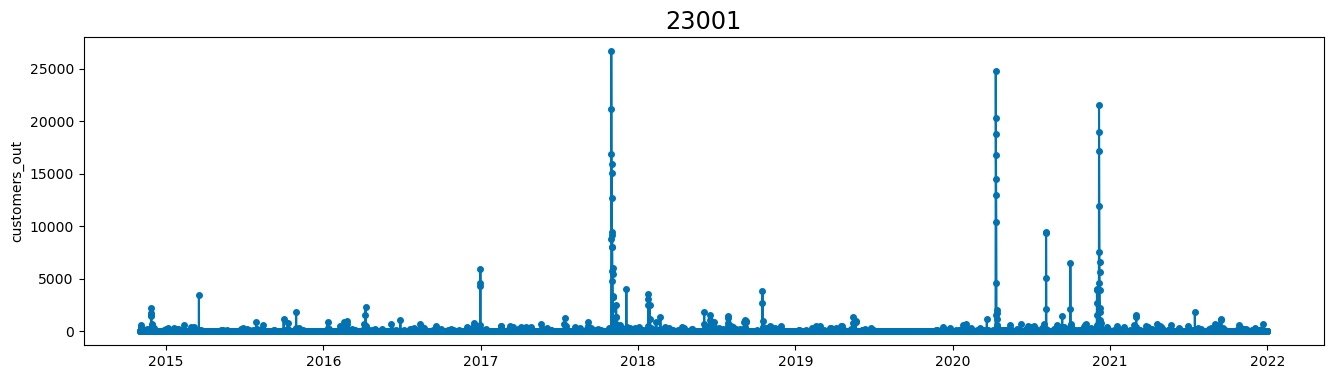

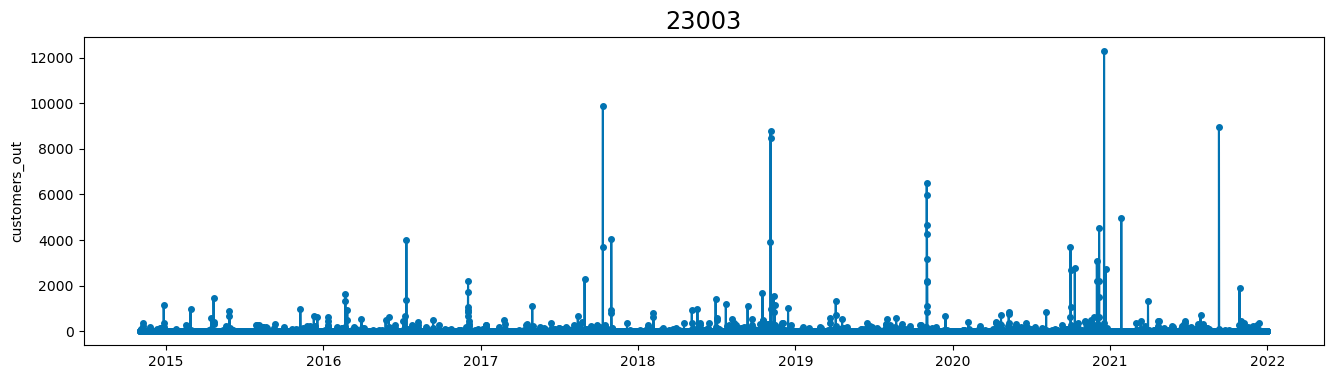

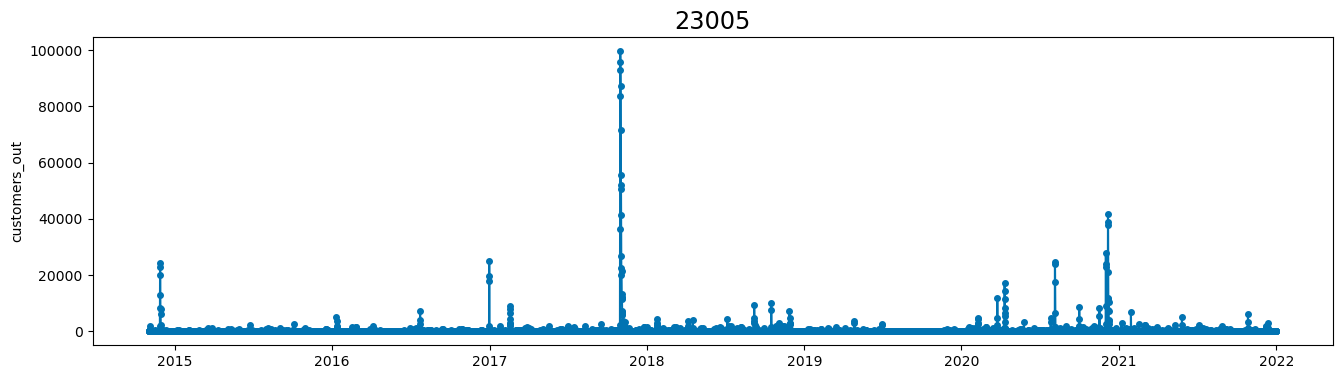

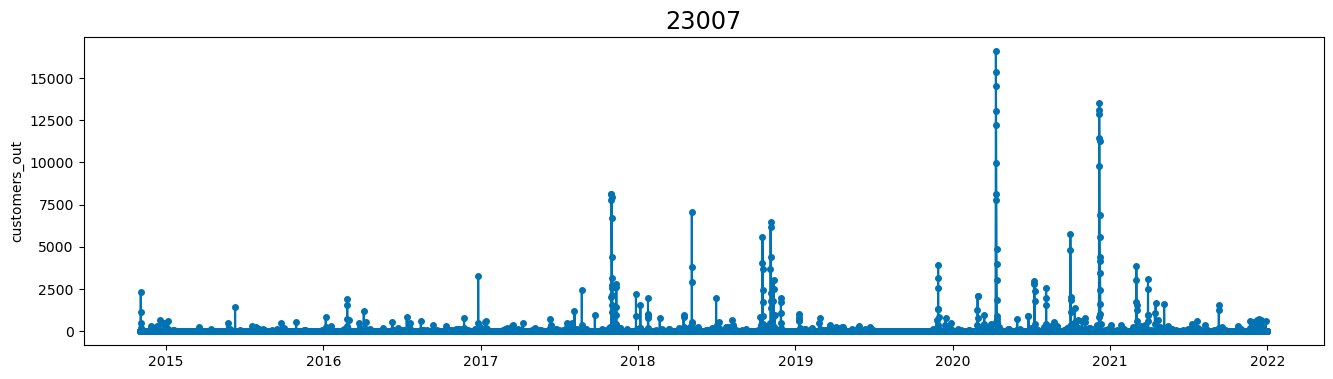

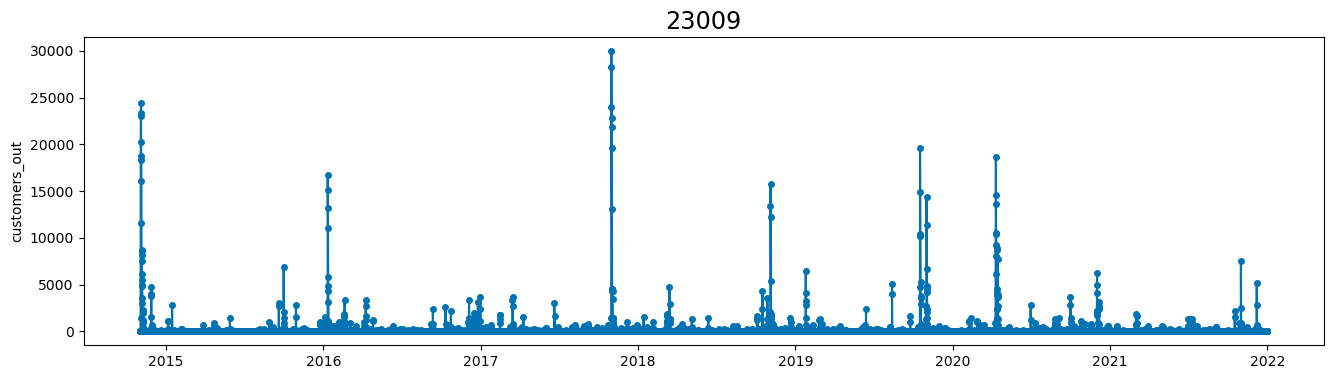

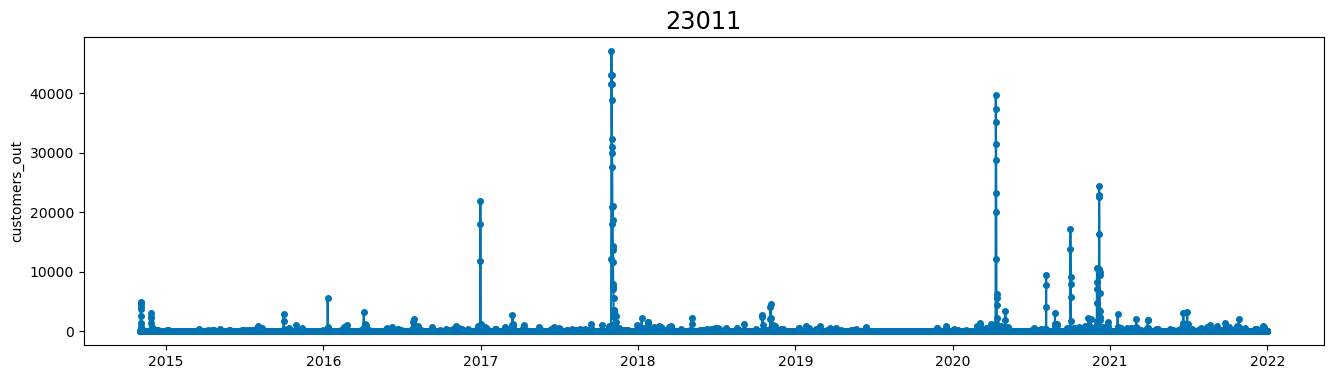

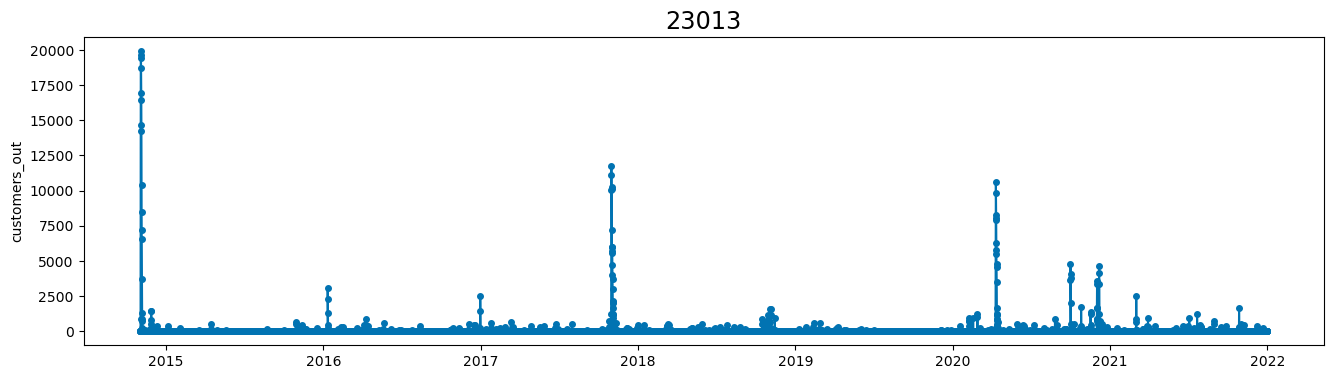

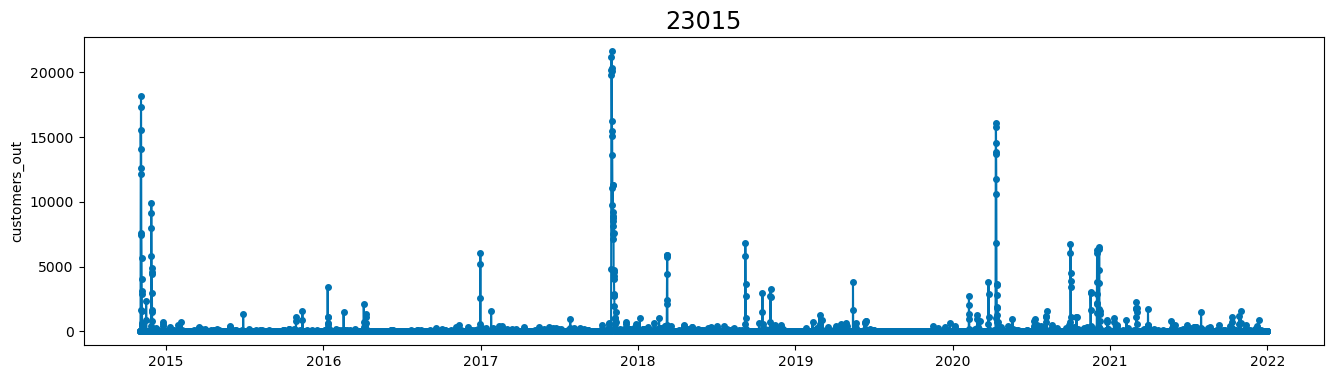

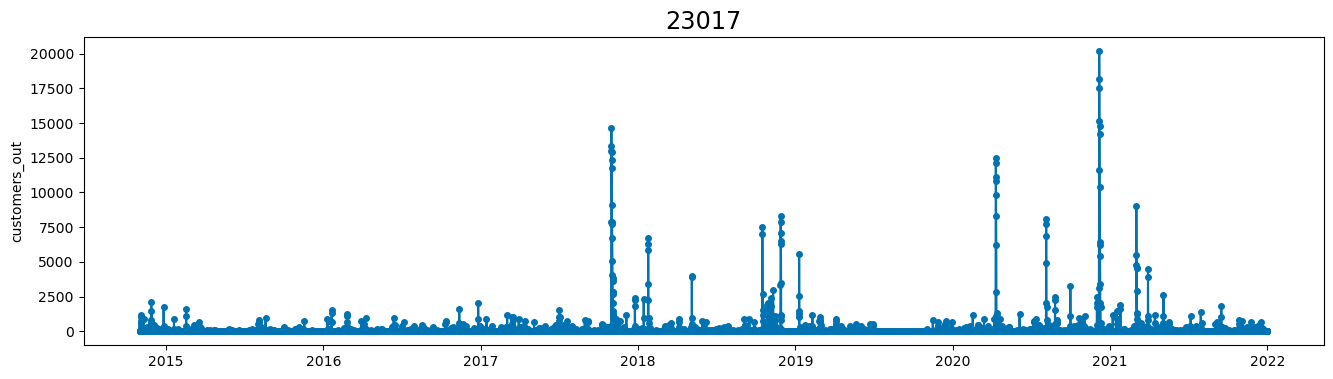

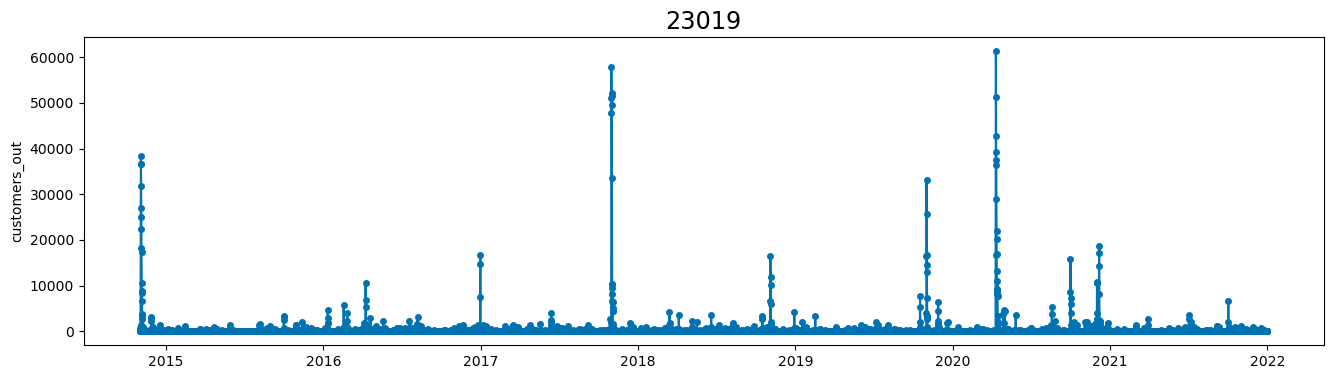

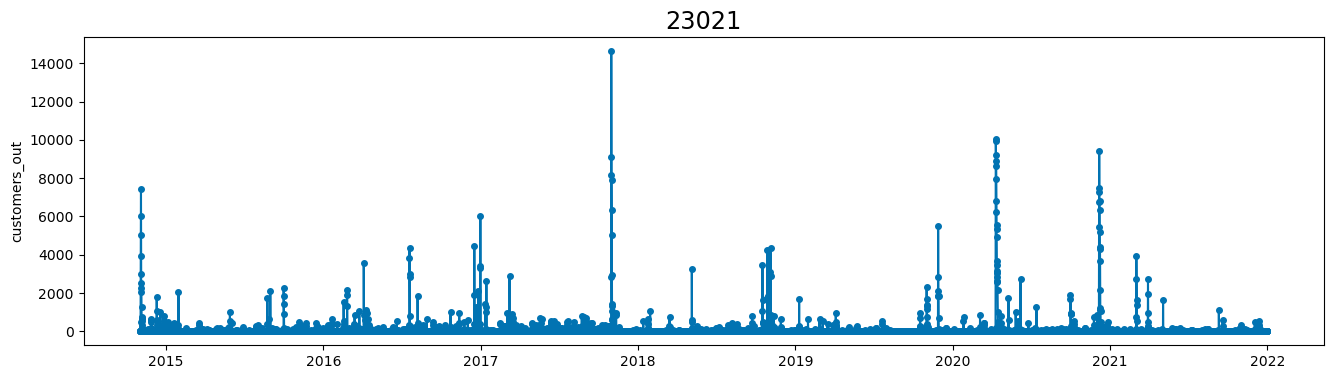

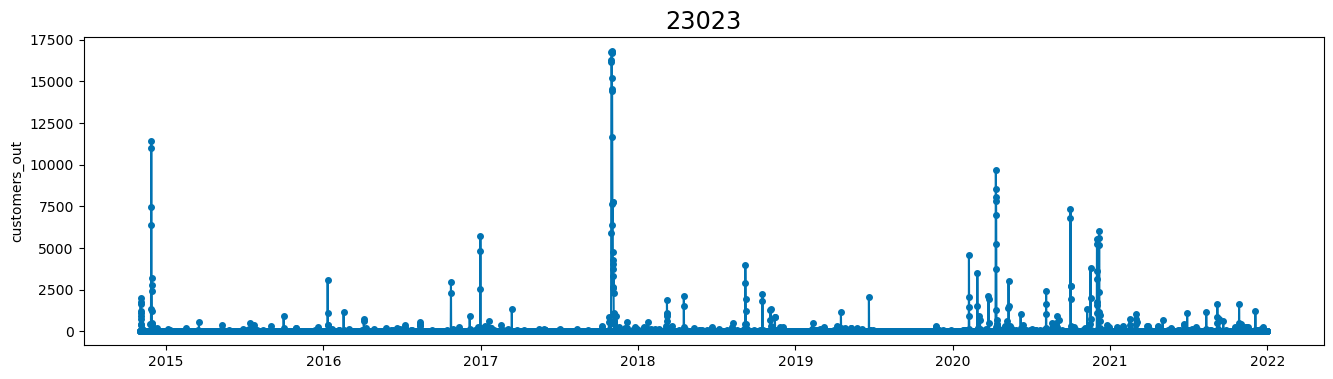

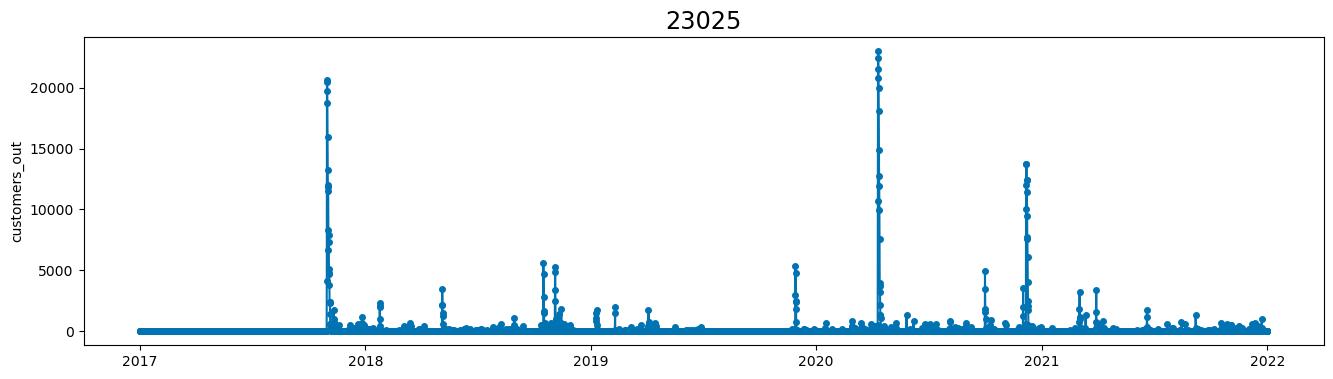

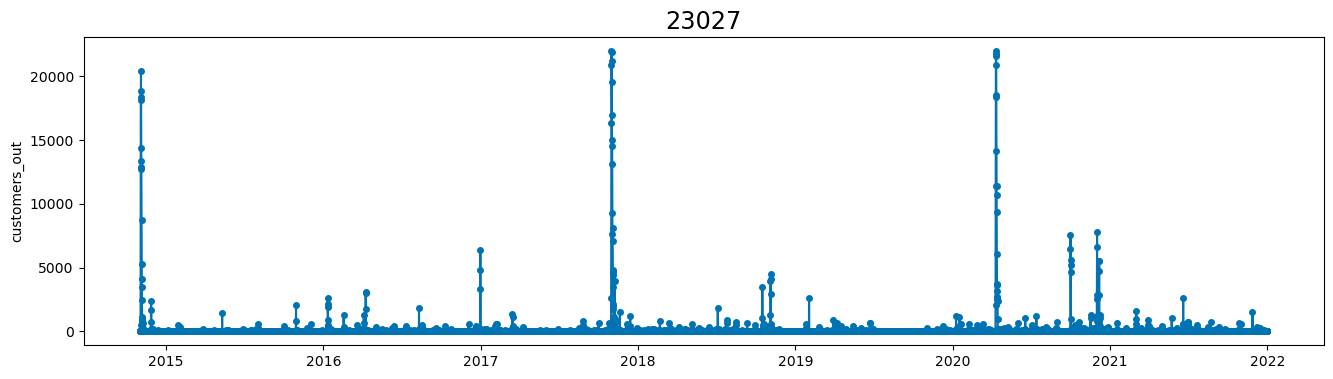

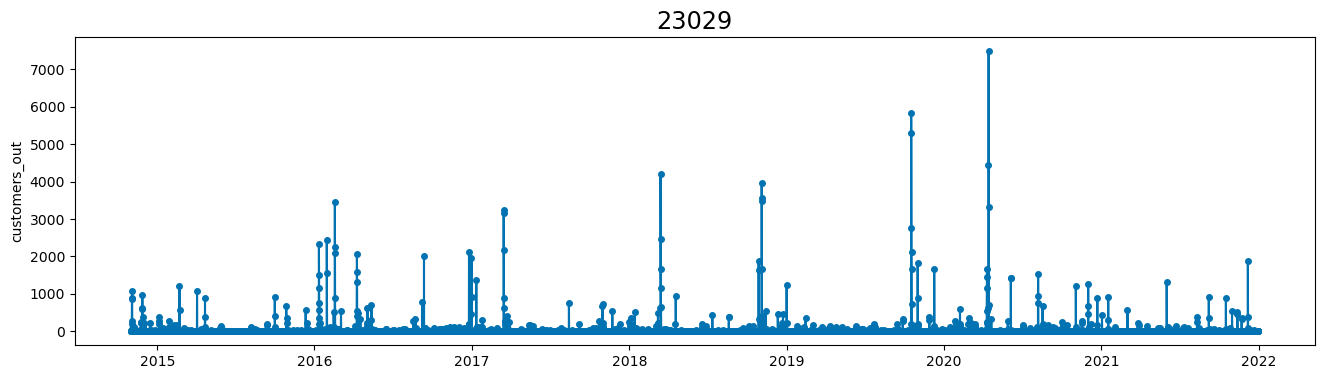

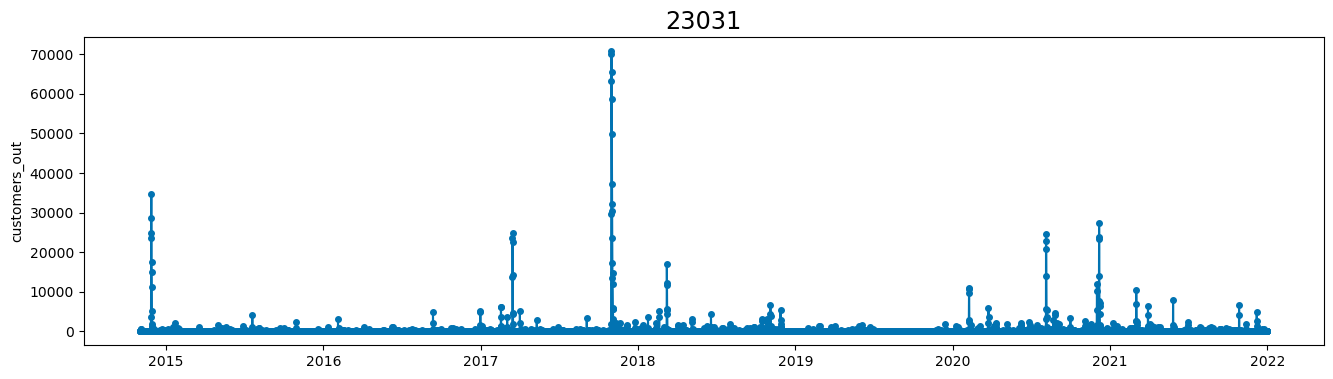

In [25]:
#For each value of fips_code, plot the value of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    plot_series(y_fips, title=fips_code)

## ACF, Stationarity, and PACF plots

We'll make an autocorrelation and partial autocorrelation plot for each of the counties.

The ACF plots suggest that there are correlations with up to 15-20 lags, which corresponds to 4-5 days. There doesn't appear to be any consistent seasonality.

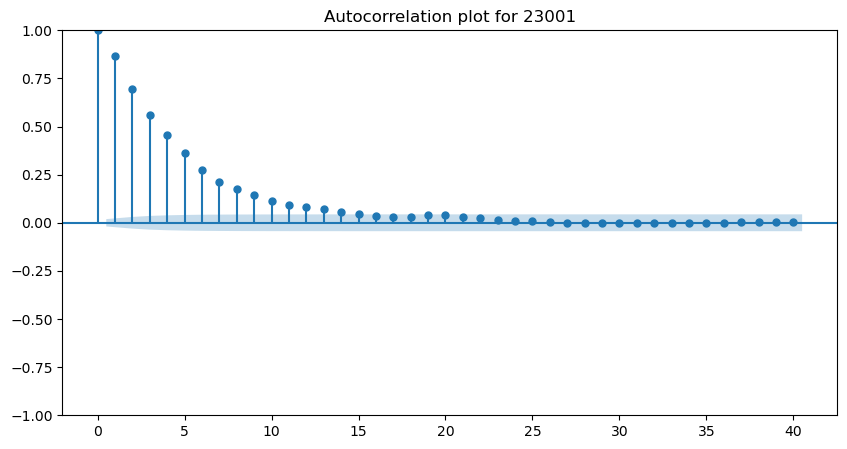

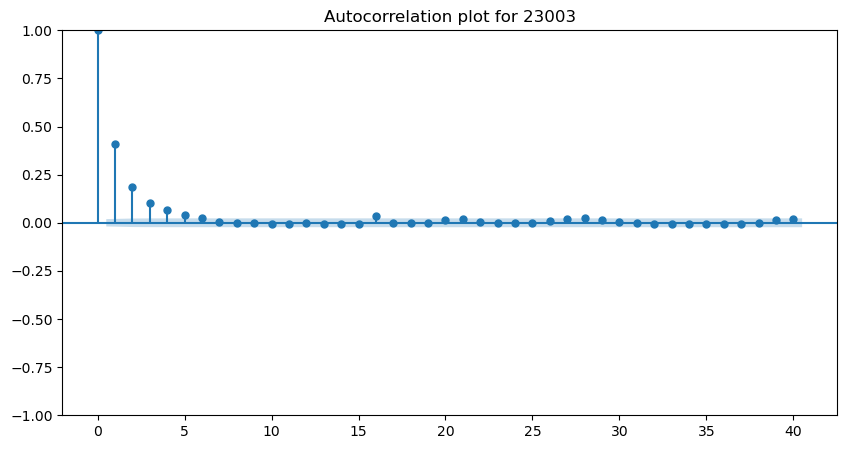

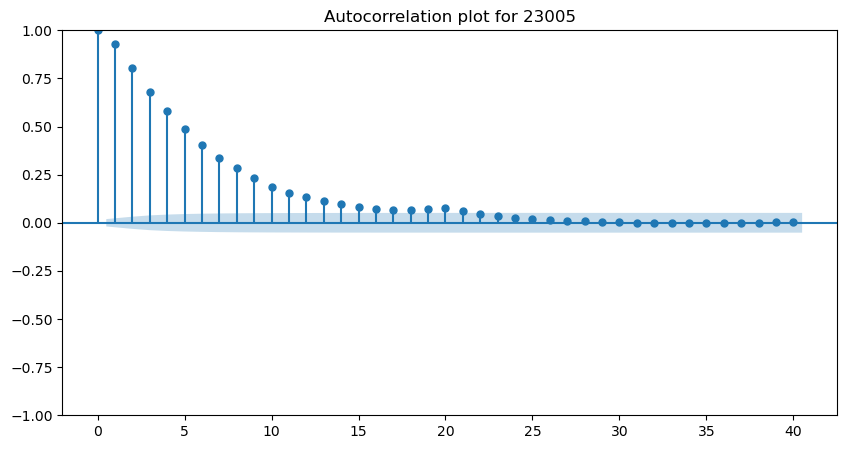

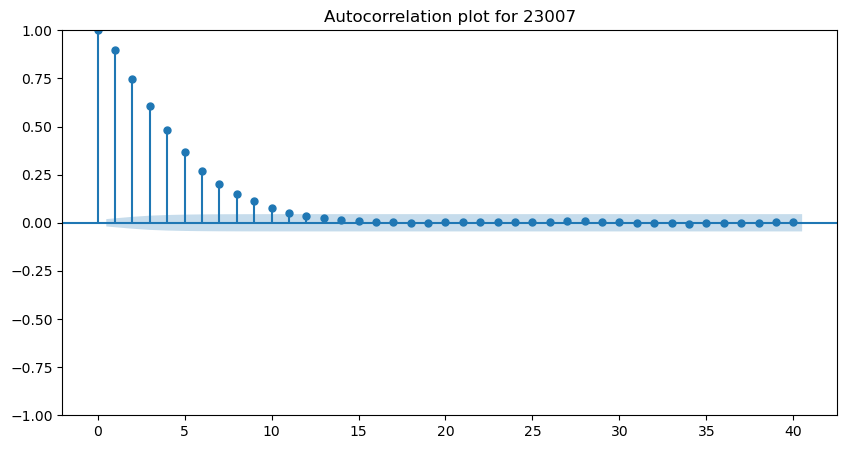

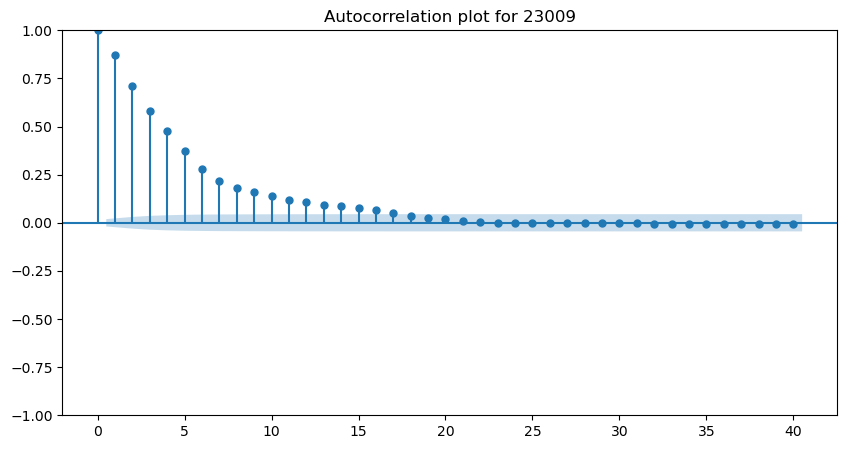

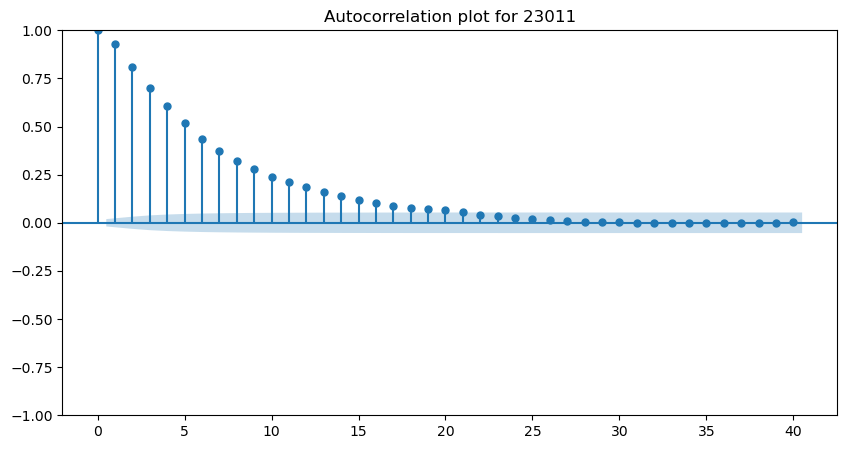

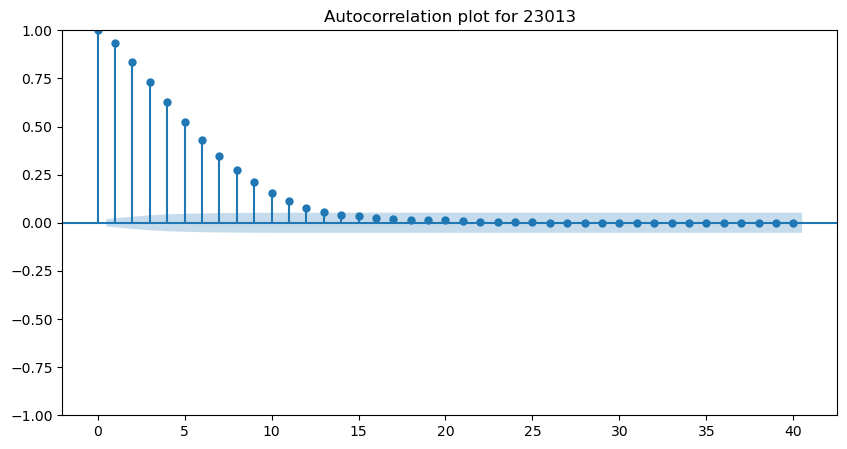

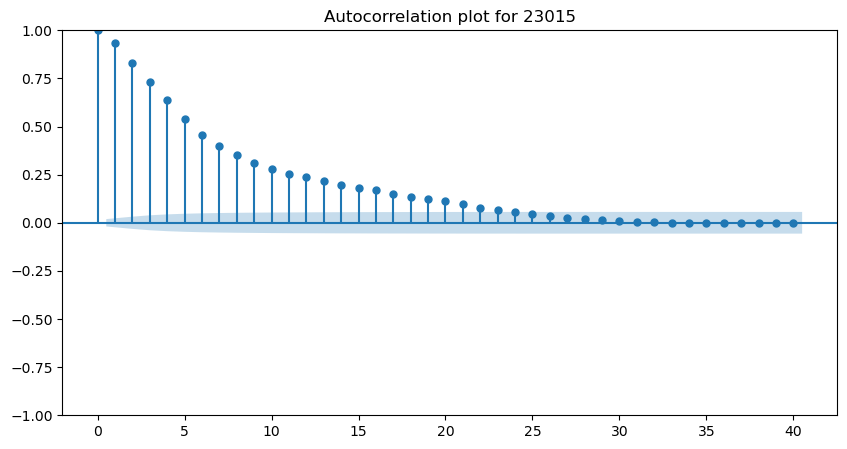

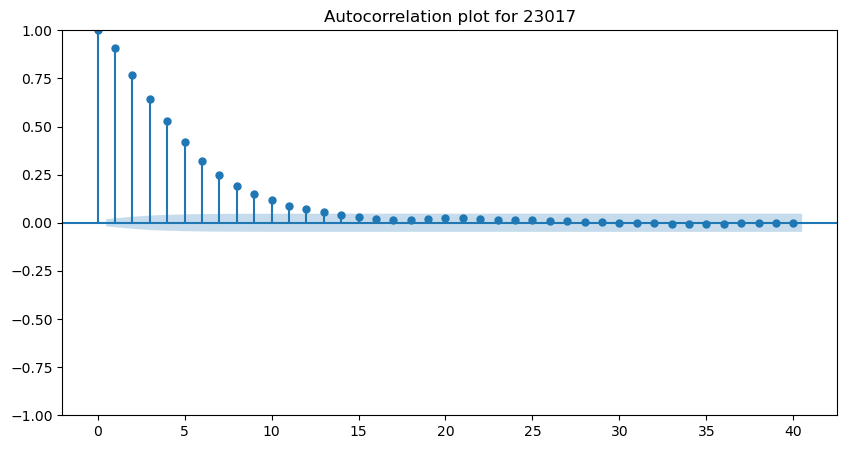

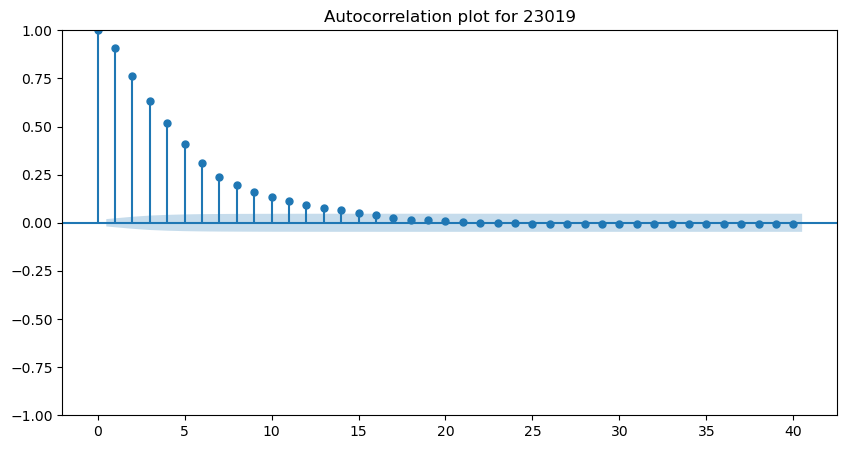

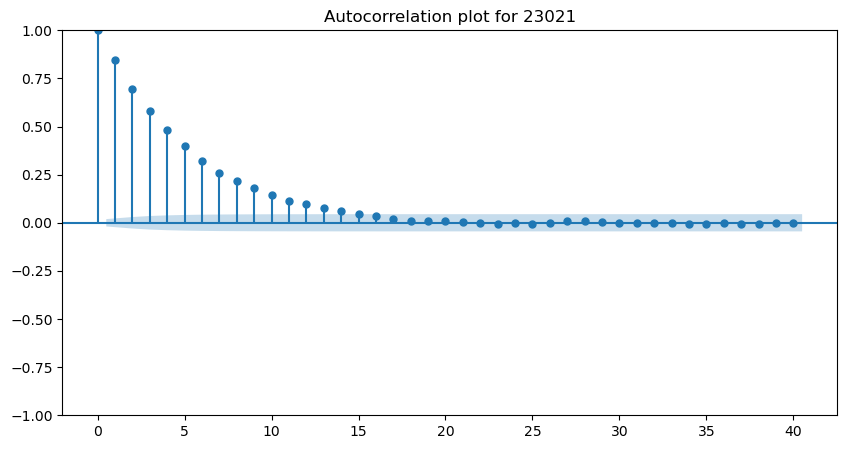

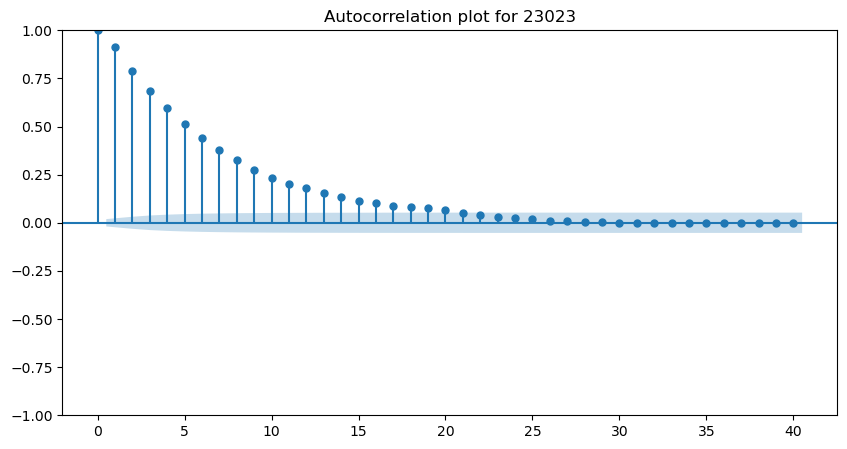

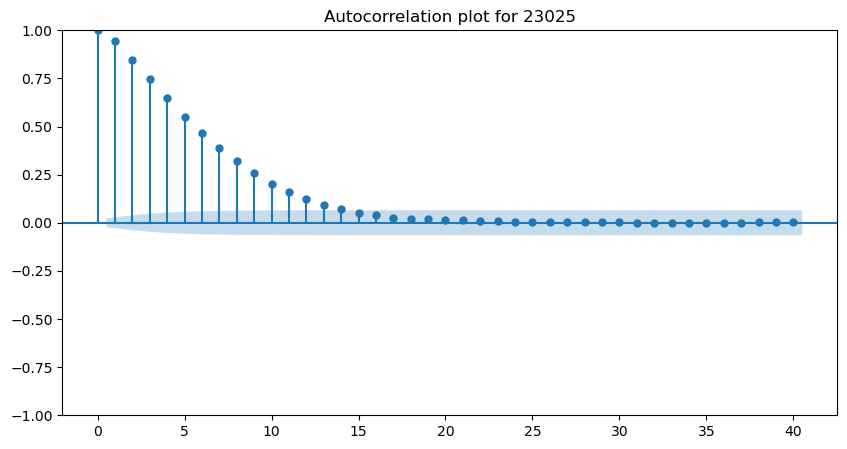

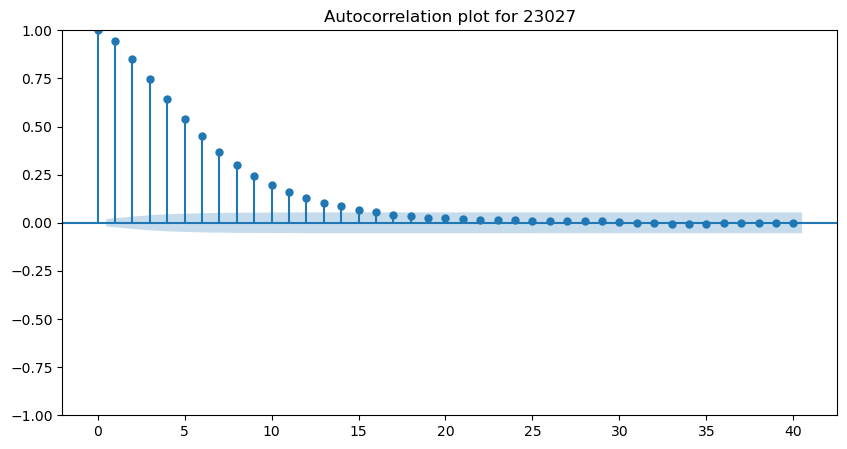

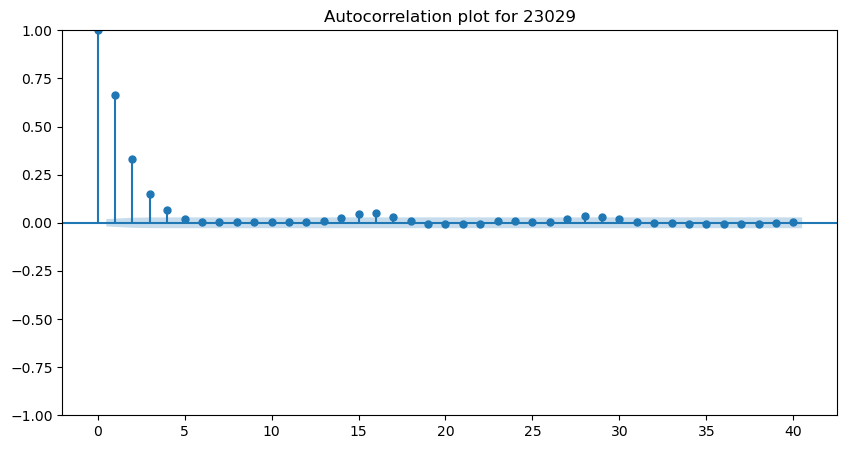

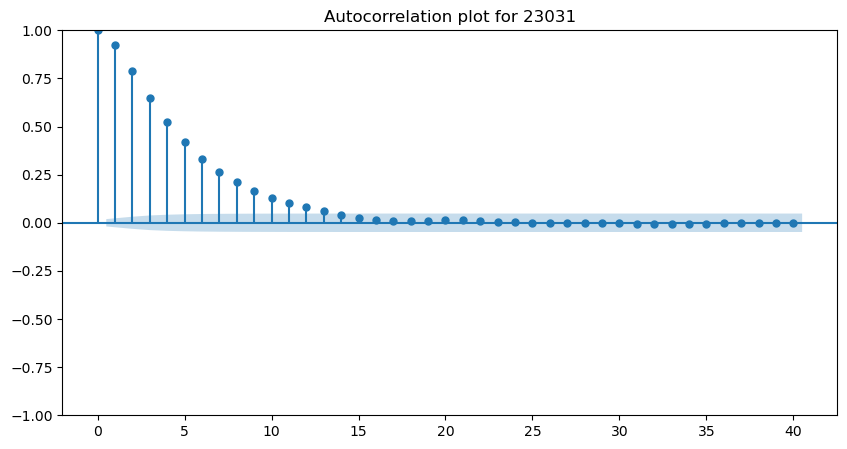

In [26]:
#For each value of fips_code use statsmodels to make an autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sm.graphics.tsa.plot_acf(y_fips['customers_out'], lags=40, ax=ax)
    plt.title(f'Autocorrelation plot for {fips_code}')
    plt.show()

### Testing for stationarity

We'll use an augmented Dickey-Fuller test. All the p-values are quite tiny, suggesting stationarity.

This suggests that an autoregressive model is appropriate.

In [27]:
# Create a numpy array to hold the fips_codes and p-values
p_values = np.zeros((16, 2))
i=0

#For each value of fips_code, run the Augmented Dickey-Fuller test
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    result = sm.tsa.stattools.adfuller(y_fips['customers_out'])
    p_values[i,0]=int(fips_code)
    p_values[i,1]=result[1]
    i=i+1
p_values

array([[2.30010000e+04, 2.02266229e-30],
       [2.30030000e+04, 0.00000000e+00],
       [2.30050000e+04, 1.05219007e-29],
       [2.30070000e+04, 0.00000000e+00],
       [2.30090000e+04, 0.00000000e+00],
       [2.30110000e+04, 2.98314558e-30],
       [2.30130000e+04, 0.00000000e+00],
       [2.30150000e+04, 1.69490413e-29],
       [2.30170000e+04, 0.00000000e+00],
       [2.30190000e+04, 0.00000000e+00],
       [2.30210000e+04, 0.00000000e+00],
       [2.30230000e+04, 1.19006282e-29],
       [2.30250000e+04, 3.05341663e-28],
       [2.30270000e+04, 9.31721772e-29],
       [2.30290000e+04, 0.00000000e+00],
       [2.30310000e+04, 0.00000000e+00]])

### PACF Plots

There is quite a bit of variation from county to county. The first and second lags are statistically significant for all counties. It isn't uncommon for the fourth and fith lags to also be statistically significant. 

This suggests we might use a fifth-order autoregressive model.

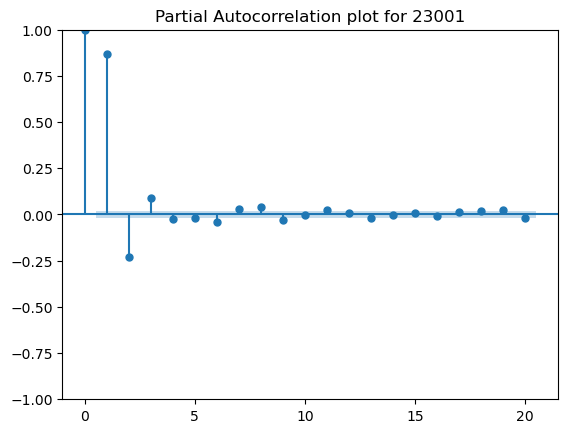

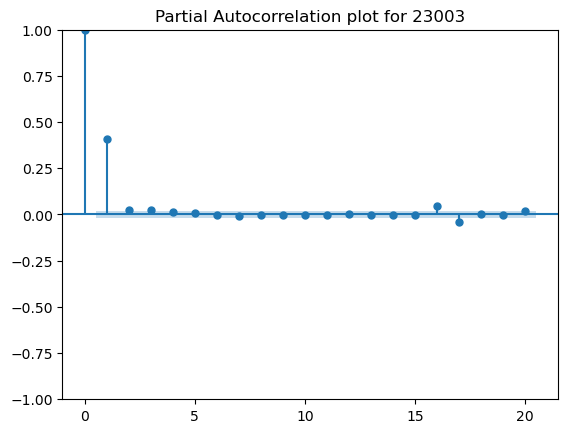

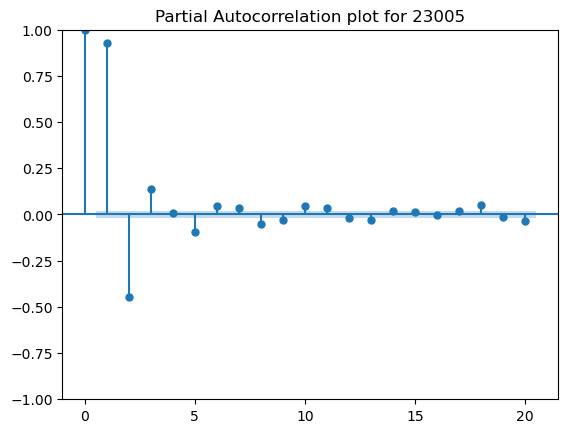

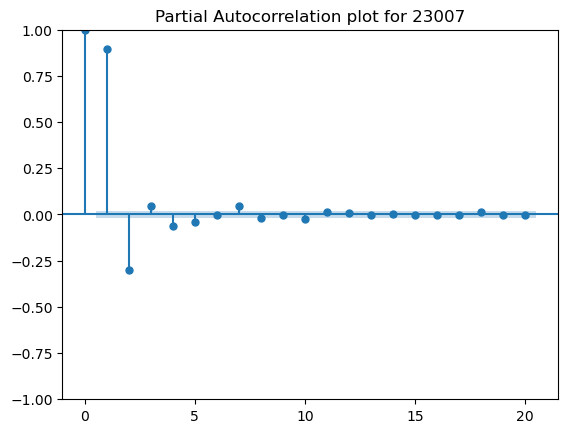

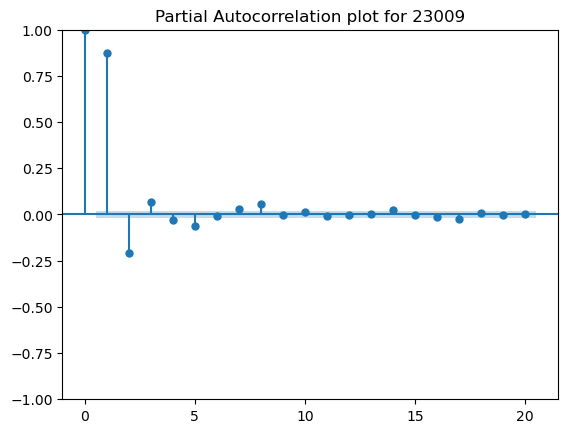

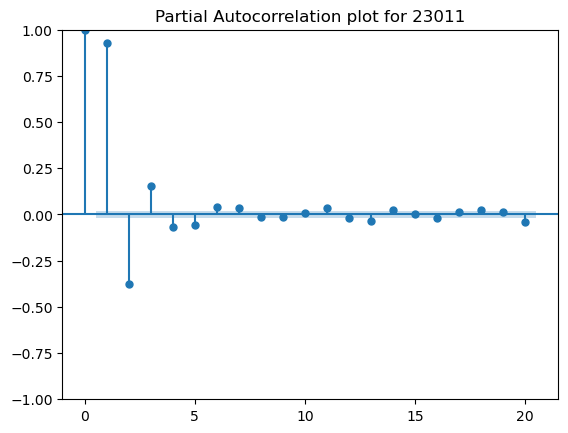

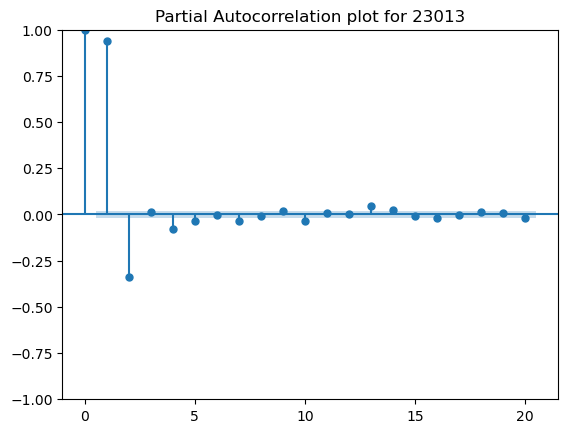

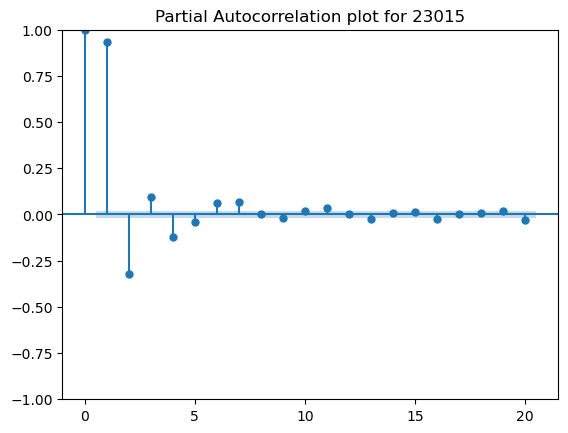

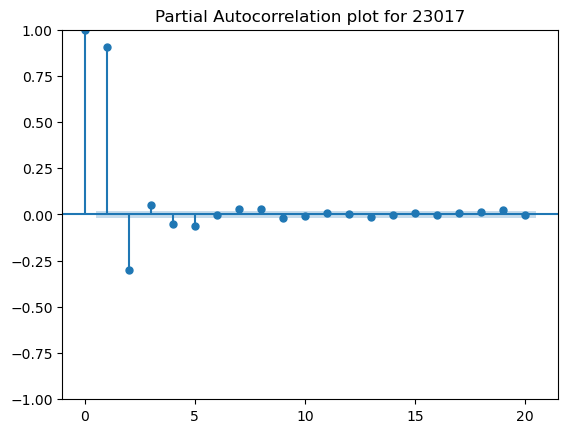

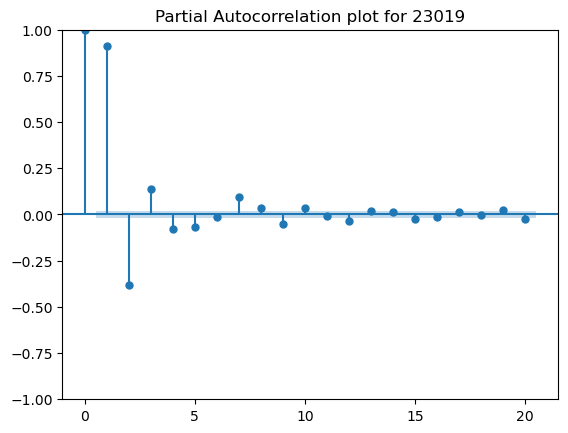

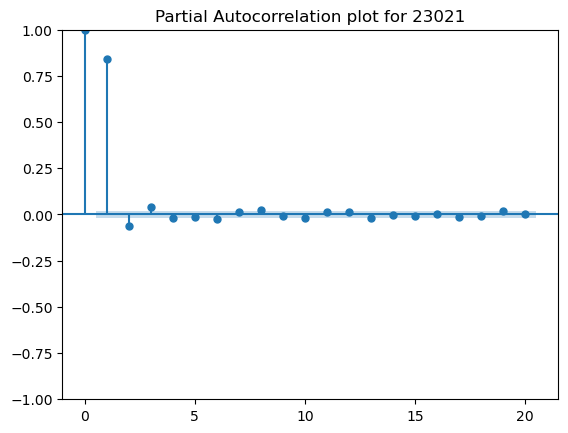

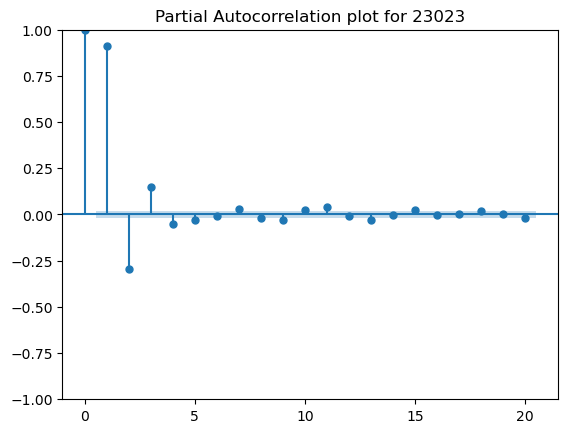

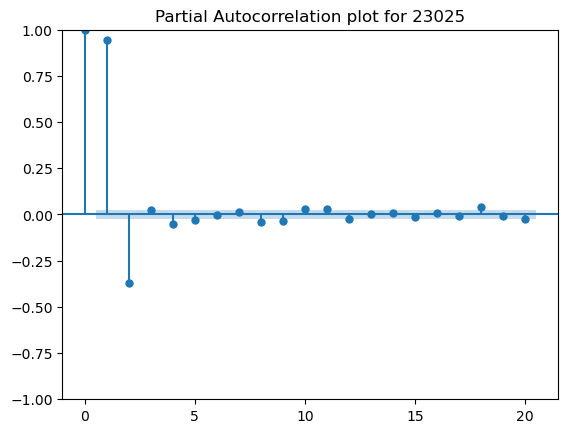

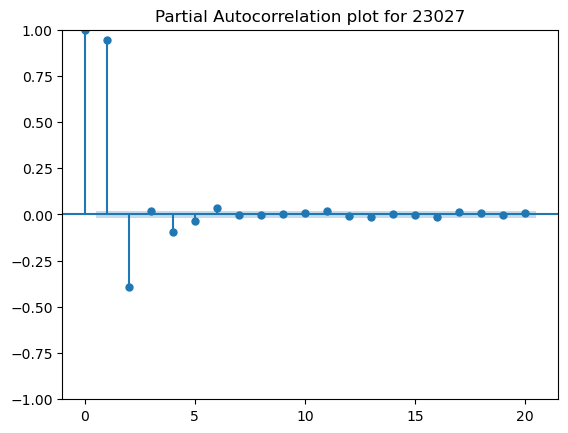

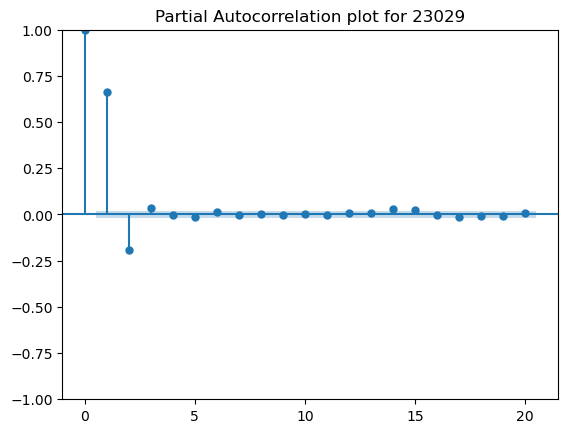

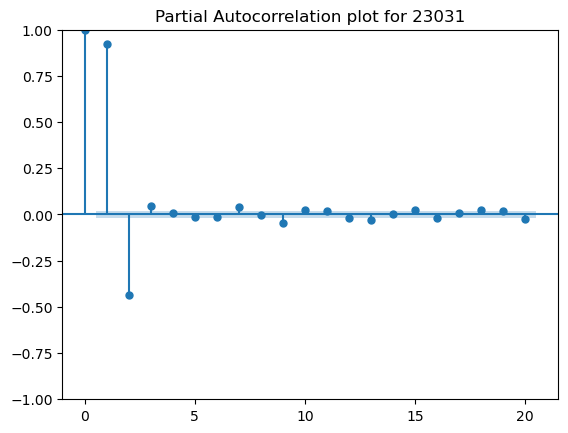

In [28]:
#For each value of fips_code make a partial autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    sm.graphics.tsa.plot_pacf(y_fips, lags=20, method='ols')
    plt.title(f'Partial Autocorrelation plot for {fips_code}')
    plt.show()

# Trying ARMIA and Naive Forecasters for Prediction

## Setting up the models

We'll make a train test split to check performance of a naive foreaster basic ARIMA model for predicting customers_out.

The ACF graphs suggested we might look at up to 20-30 lags. So we'll use 30 lags as the test horizon for the ARIMA model.

For the naive forecaster we'll use values from the previous year, so 1460 lags.

Then we'll make graphs to compare the predicted and actual values. Some of the ARIMA predictions look pretty wonky...

In [ ]:
y = y.sort_index()

y_train, y_test = temporal_train_test_split(y, test_size=30)
# Note that y_train and y_test are each a dataframe with values of customers_out and a multiindex with fips_code and datetime indices

fh = ForecastingHorizon(y_test.index.get_level_values('datetime').unique(), is_relative=False)

forecaster_arima = ARIMA(order=(5, 1, 0))
forecaster_arima.fit(y_train)

forecaster_naive = NaiveForecaster(strategy="last", sp=1460)
forecaster_naive.fit(y_train)

y_pred_arima = forecaster_arima.predict(fh)
y_pred_naive = forecaster_naive.predict(fh)

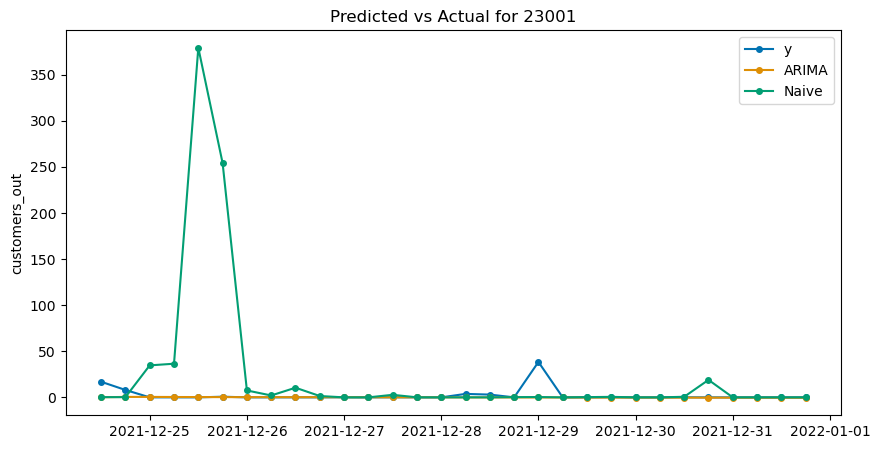

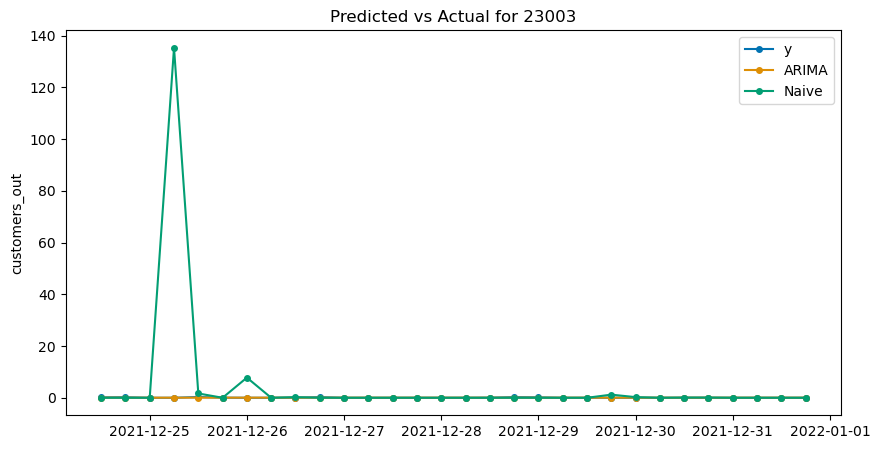

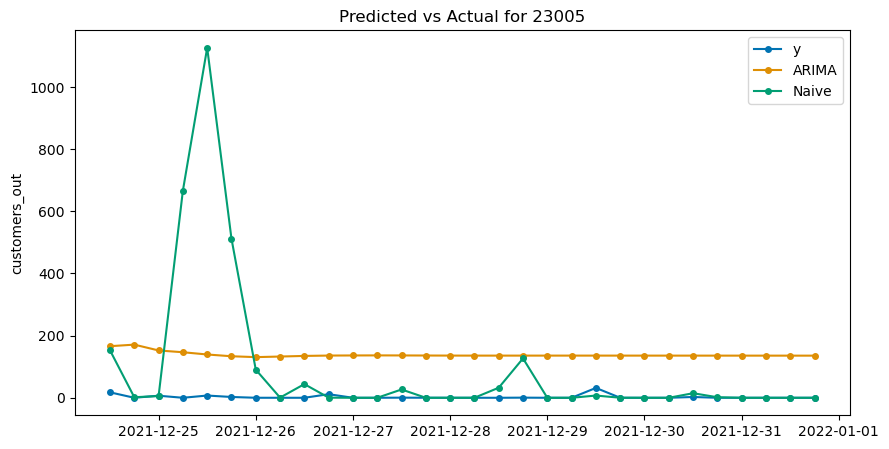

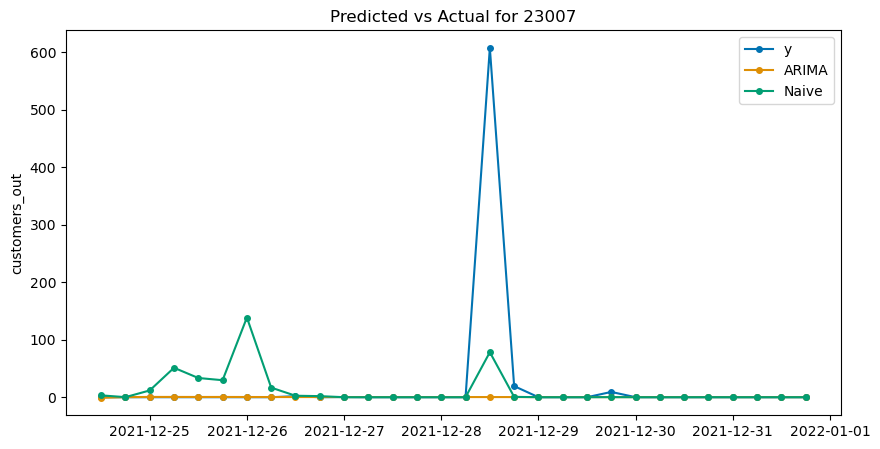

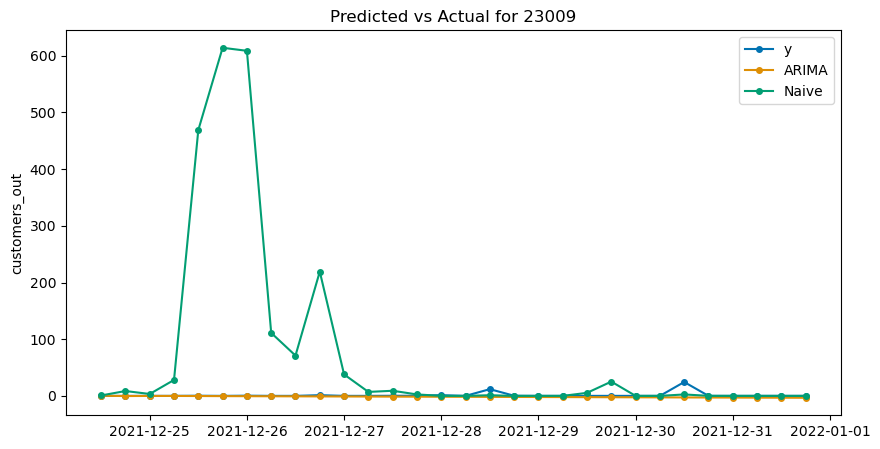

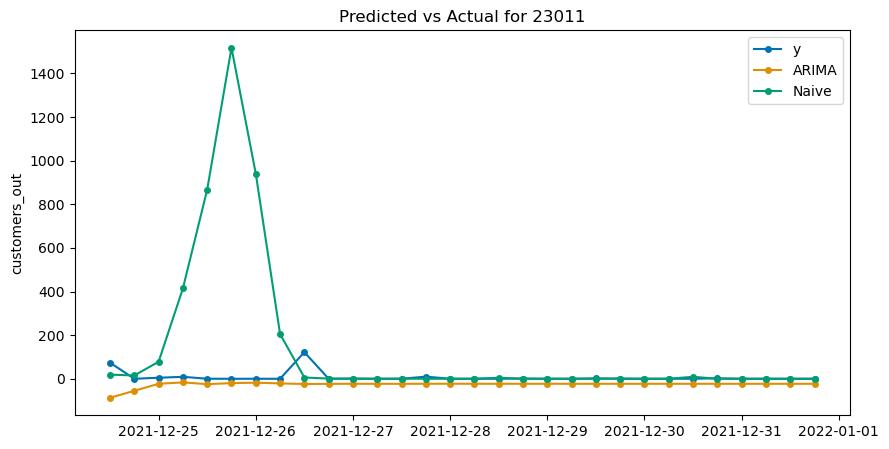

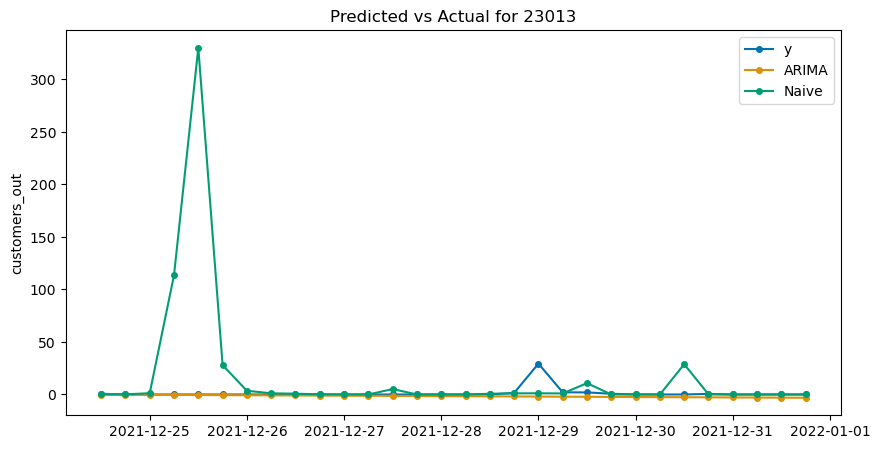

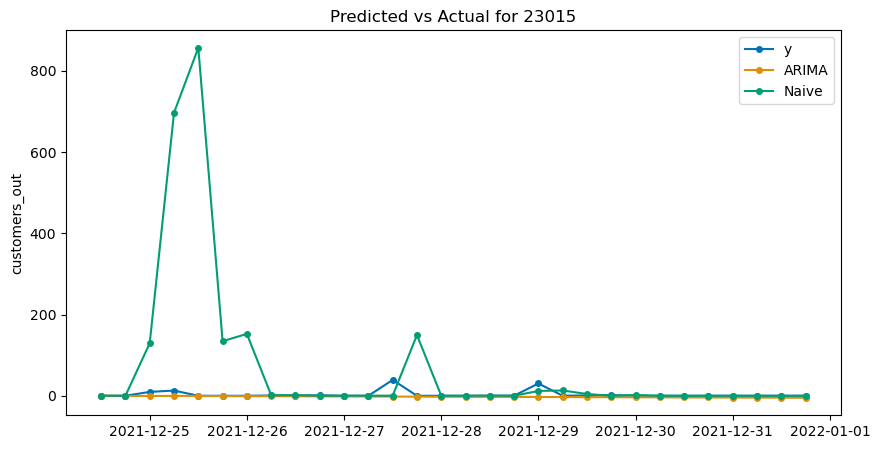

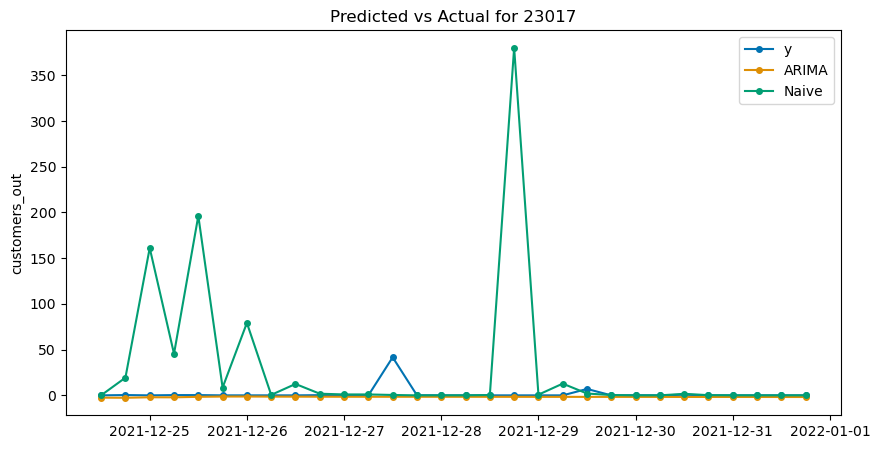

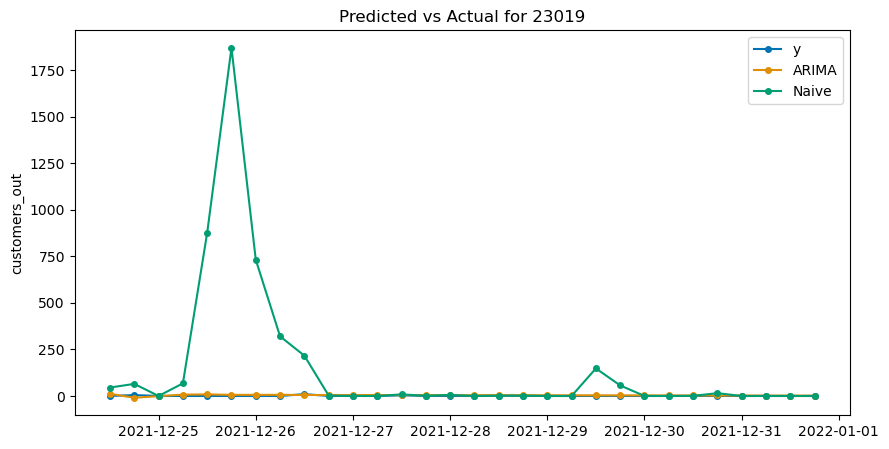

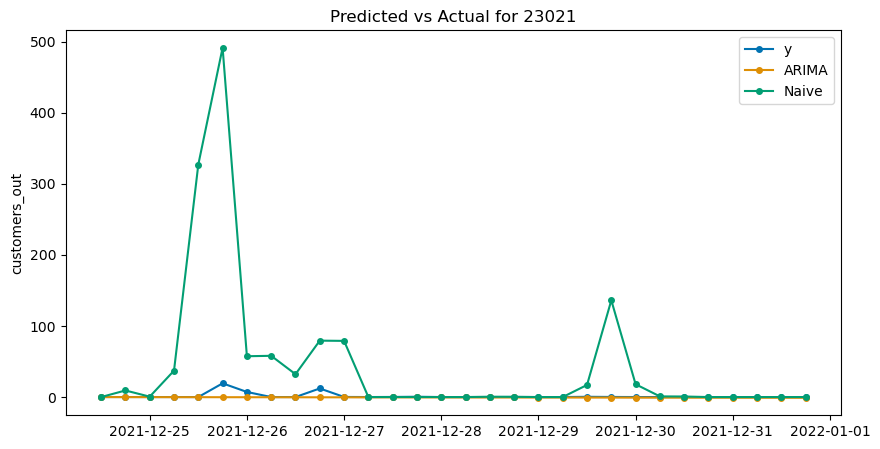

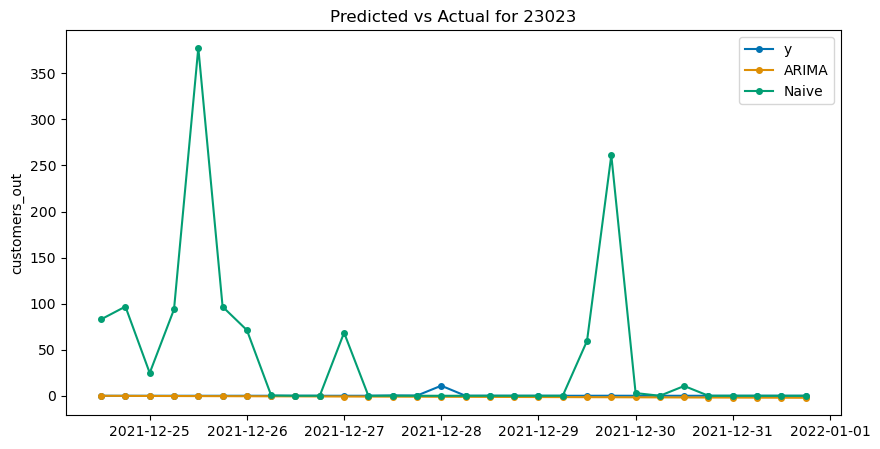

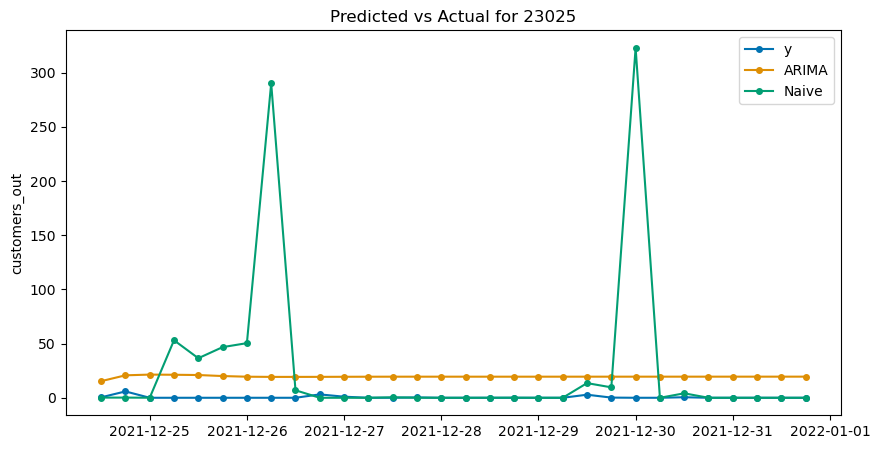

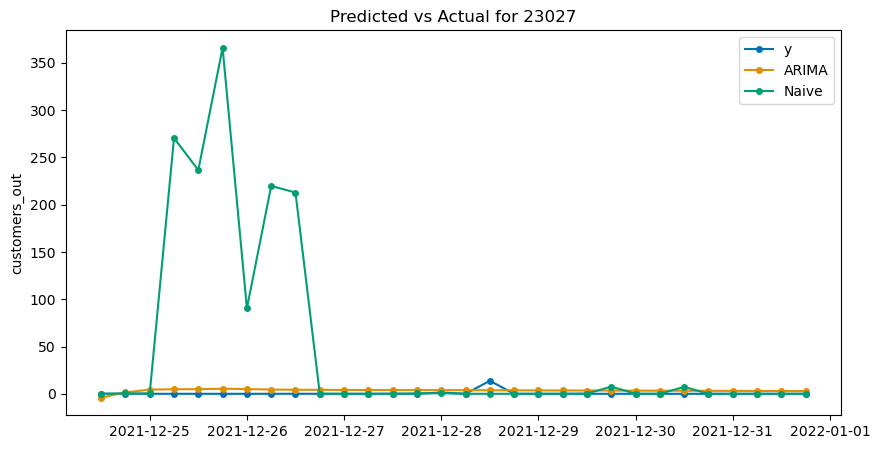

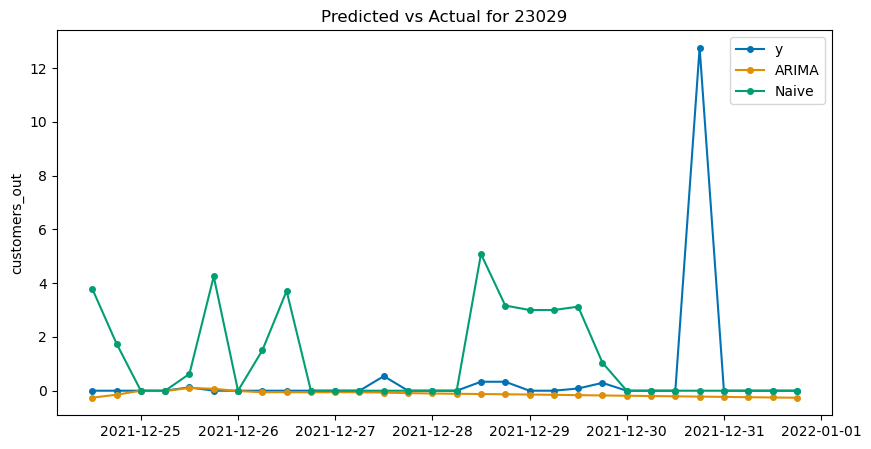

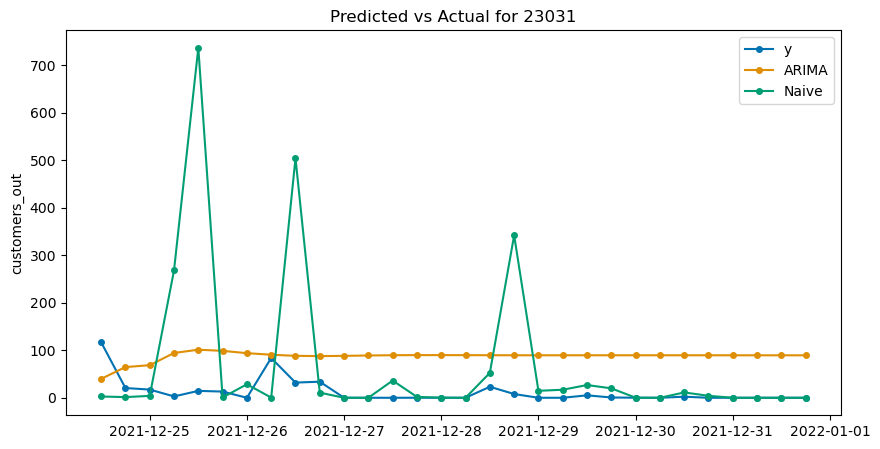

In [33]:
# Make plots for each fips_code to compare actual and predicted values on the test set
for fips_code in y.index.get_level_values(0).unique():
    y_train_fips = y_train.loc[fips_code]
    y_test_fips = y_test.loc[fips_code]
    y_pred_a = y_pred_arima.loc[fips_code]
    y_pred_n = y_pred_naive.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_a, y_pred_n, labels=["y", "ARIMA","Naive"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

### Evaluating Model Performance

From sktime documentation:

The next step is to specify a forecasting metric. These are functions that return a number when input with prediction and actual series. They are different from sklearn metrics in that they accept series with indices rather than np.arrays. Forecasting metrics can be invoked in two ways:

- using the lean function interface, e.g., mean_absolute_percentage_error which is a python function (y_true : pd.Series, y_pred : pd.Series) -> float
- using the composable class interface, e.g., MeanAbsolutePercentageError, which is a python class, callable with the same signature

In [14]:
#Evaluating the performance of the model

# We'll display the output in a Pandas dataframe because it looks nice.

mape = MeanAbsolutePercentageError(symmetric=False)
mape.get_tag("lower_is_better")
rmse = MeanSquaredError(square_root = True)

#Create a data frame to hold the fips code, MAPE for ARIMA and Naive predictions, and RMSE for ARIMA and Naive predictions
results = pd.DataFrame()
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = y_test.loc[fips_code]
    y_pred_a = y_pred_arima.loc[fips_code]
    y_pred_n = y_pred_naive.loc[fips_code]
    new_row = pd.DataFrame(np.zeros((1, 5)), columns=['fips_code', 'MAPE_ARIMA', 'MAPE_Naive', 'RMSE_ARIMA', 'RMSE_Naive'])
    new_row['fips_code'] = fips_code
    new_row['MAPE_ARIMA'] = mape(y_test_fips, y_pred_a)
    new_row['MAPE_Naive'] = mape(y_test_fips, y_pred_n)
    new_row['RMSE_ARIMA'] = rmse(y_test_fips, y_pred_a)
    new_row['RMSE_Naive'] = rmse(y_test_fips, y_pred_n)
    results = pd.concat([results, new_row], ignore_index=True)

results

#If we wanted to do this with a numpy array, we could use the following code:
#mapes = np.zeros((n_counties, 3))
#i=0
#for fips_code in y.index.get_level_values(0).unique():
#    y_test_fips = y_test.loc[fips_code]
#    y_pred_a = y_pred_arima.loc[fips_code]
#    y_pred_n = y_pred_naive.loc[fips_code]
#    mapes[i, 0] = int(fips_code)
#    mapes[i,1] = mape(y_test_fips, y_pred_a)
#    mapes[i,2] = mape(y_test_fips, y_pred_n)
#    i=i+1
#mapes

,fips_code,MAPE_ARIMA,MAPE_Naive,RMSE_ARIMA,RMSE_Naive
0,23001,7.212668e+14,7.374019e+16,7.854005,84.268282
1,23003,1.486749e+14,2.176740e+16,0.089576,24.751793
2,23005,3.731453e+17,1.121647e+17,136.274518,258.417429
3,23007,1.063769e+15,4.300938e+16,111.013821,100.862532
4,23009,5.434050e+15,1.369782e+17,5.873769,185.804891
5,23011,5.045159e+16,4.002011e+17,46.698239,372.718425
6,23013,4.895534e+15,7.708036e+16,6.117328,64.416432
7,23015,7.622553e+15,1.963319e+17,10.503458,206.642939
8,23017,5.241944e+15,9.883525e+16,8.228670,85.558131
9,23019,8.903462e+15,5.800761e+17,5.280411,407.261322


## Trying ARIMA for Prediction with a Sliding Window

Note that the sliding window requires a lot more time to run than a single test-train split.

So we'll start by shortening the dataset to the most recent 200 observations of y

Documentation here: https://www.sktime.net/en/stable/examples/forecasting/window_splitters.html

Also note that sktime has an evaluate function that does some sort of auto-evaluation for cross-validation:
https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.model_evaluation.evaluate.html

### Set up the ARIMA forecaster and evaluate it using SlidingWindowSplitter

Note that the fitting process generates a lot of errors:
"ConvergenceWarning: Maximum Likelihood optimization failed to converge"

When we call the evaluate method using "refit" instead of "update", the proces fails with the error:
LinAlgError: Schur decomposition solver error

The internet suggests adding the enforce_stationarity=False and enforce_invertibility=False options to the forecaster might solve this...
And it appears to work

Note that there are a lot of zeroes in the y data, which could be the underlying issue

In [ ]:
# Set up the ARIMA forecaster with order 5
forecaster_arima = ARIMA(order=(5, 1, 0), enforce_stationarity=False, enforce_invertibility=False)

# Let y_small be the most recent 200 observations of y for each value of fips_code
y_small = y.groupby(level=0).tail(200)

fh = np.arange(1, 13)   #Forecasting horizon - we'll need this later
#fh = ForecastingHorizon(13, is_relative=False)

# Define the SlidingWindowSplitter
sw = SlidingWindowSplitter(
    window_length=28,       # Length of the training window
    fh = np.arange(1,13),   # Forecasting horizon
    step_length=1)          # Step length between windows
    

### Trying the evaluate method

This is an "All-in-one statistical performance benchmarking utility for forecasters which runs a simple backtest experiment and returns a summary pd.DataFrame."

This returns results, which is a pd.DataFrame that contains several columns with information regarding each refit/update and prediction of the forecaster. Row index is splitter index of train/test fold in cv. Entries in the i-th row are for the i-th train/test split in cv. Columns are as follows:
- test_{scoring.name}: (float) Model performance score. If scoring is a list, then there is a column withname test_{scoring.name} for each scorer.
- fit_time: (float) Time in sec for fit or update on train fold.
- pred_time: (float) Time in sec to predict from fitted estimator.
- len_train_window: (int) Length of train window.
- cutoff: (int, pd.Timestamp, pd.Period) cutoff = last time index in train fold.
- y_train: (pd.Series) only present if return_data=True, train fold of the i-th split in cv, used to fit/update the forecaster.
- y_pred: (pd.Series) present if return_data=True, forecasts from fitted forecaster for the i-th test fold indices of cv.
- y_test: (pd.Series) present if return_data=True, testing fold of the i-th split in cv, used to compute the metric.
- fitted_forecaster: (BaseForecaster) present if return_model=True, fitted forecaster for the i-th split in cv.

In [36]:
# Evaluate the forecaster using the SlidingWindowSplitter
# Note that this can take a while to run (nearly 5 minutes even with just y_small); I tried using "loky" for the backend without any speedup
# It's producing ConvergenceWarning errors. This could be addressed by:
#  - increasing the maximum number of iterations by setting maxiter in the fit method
#  - or by using a different optimization routine, such as Nelder-Mead (method='nm')
#  - or we could suppress the warning using warnings.simplefilter('ignore', category=ConvergenceWarning)

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

results = evaluate(
    forecaster=forecaster_arima,
    cv=sw,
    y=y_small,
    X=None,             # This works with exogeneous variables; predictions are made using predict/predict_proba, or predict_quantiles depending on scoring
    strategy="refit",  # Options are "update" and "refit" (which will reset and fit forecaster via fit), verses updating forecaster via "update"
    scoring=MeanSquaredError(square_root = True),       # None defaults to MeanAbsolutePercentageError(symmetric=True). Options at: https://www.sktime.net/en/stable/api_reference/performance_metrics.html
    return_data=True,   # True means it returns three pd.Series columns for y_train, y_pred, and y_test
    error_score="raise",
    backend=None       # (default is None) Parallelization backend; runs parallel evaluate if specified and strategy="refit"; recommendation to use "dask" or "loky"
)

/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

### Make plots (one per county) of the predicted vs actual values for the first sliding window

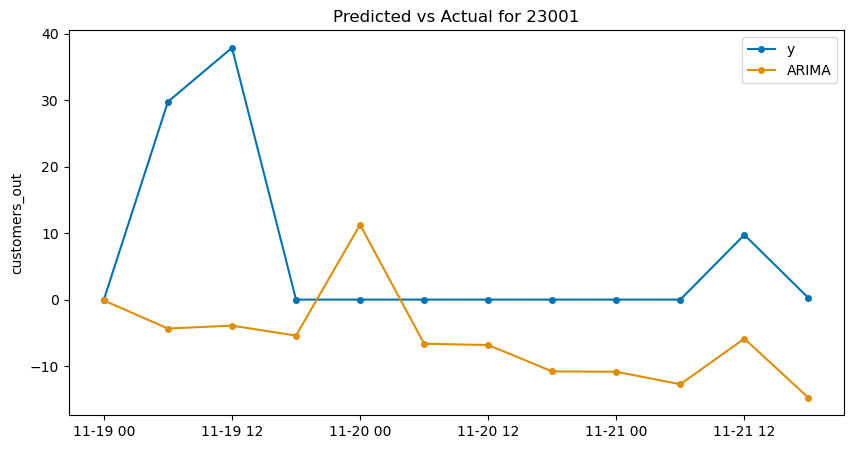

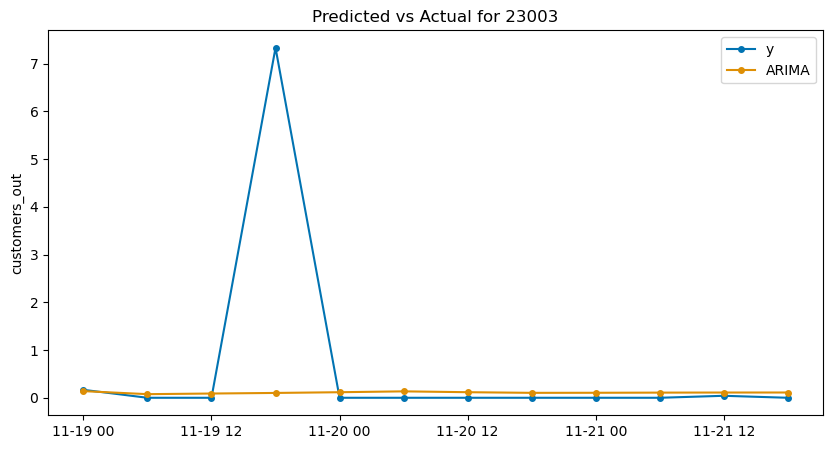

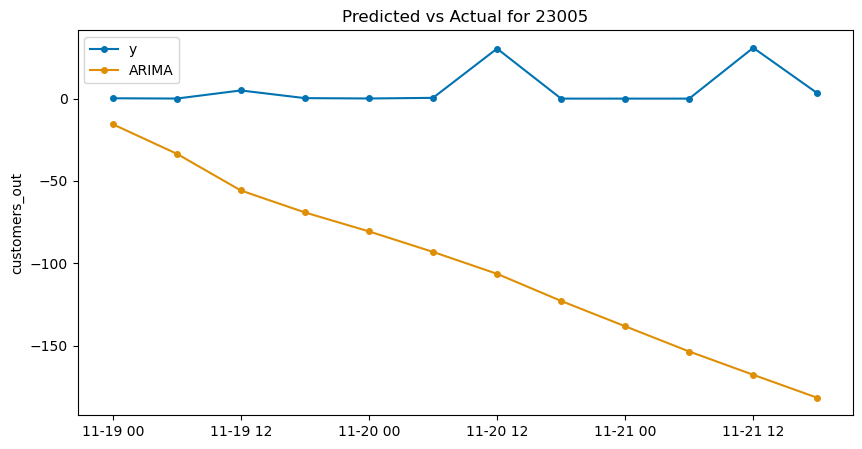

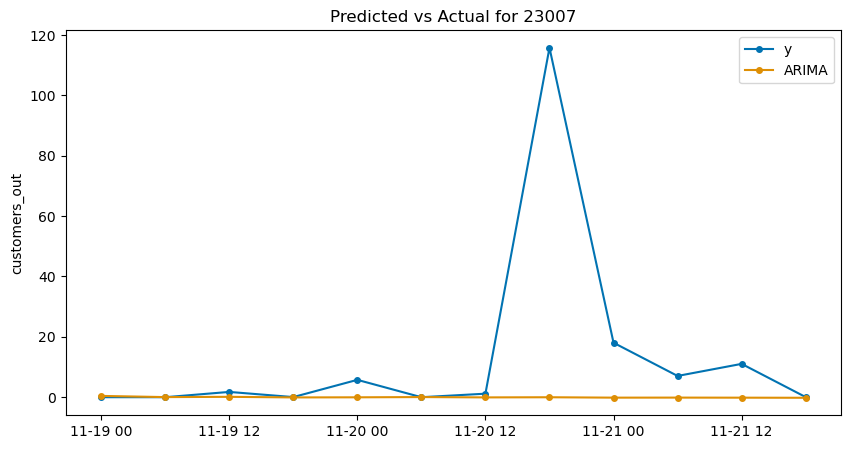

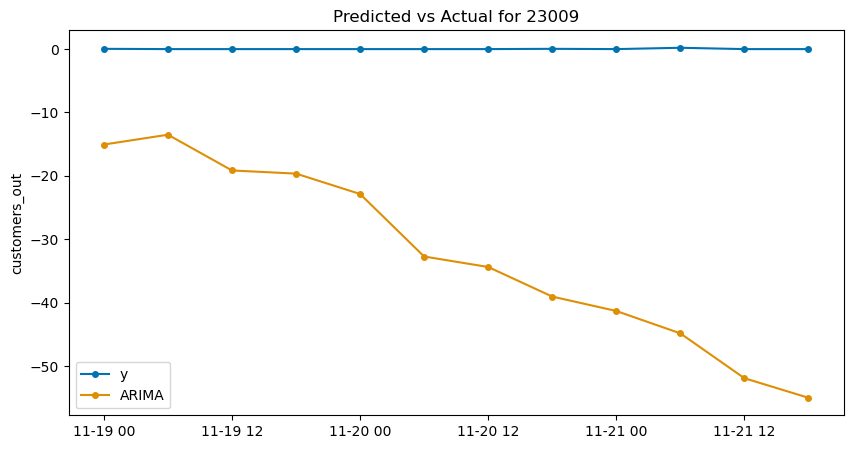

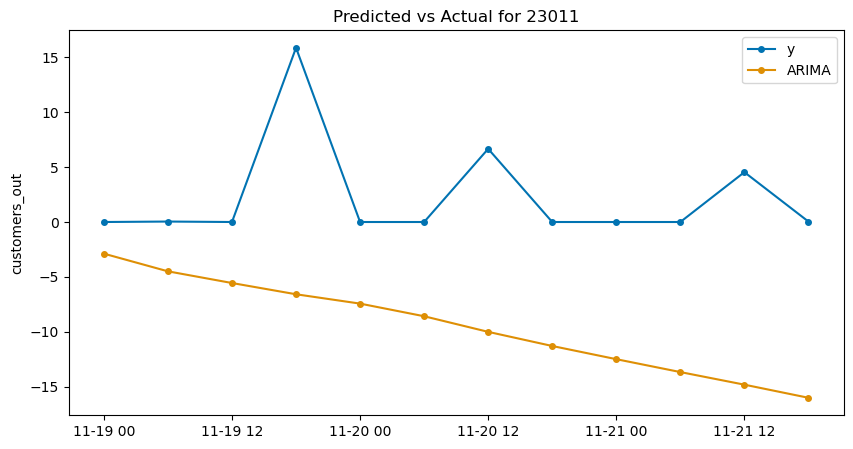

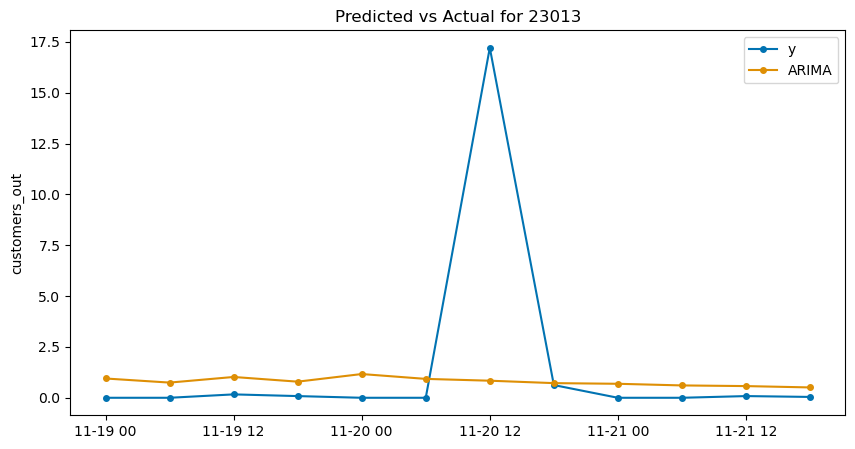

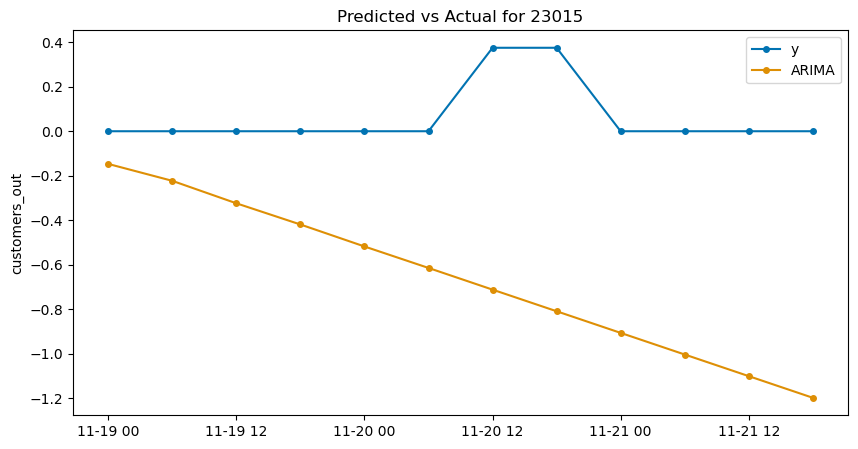

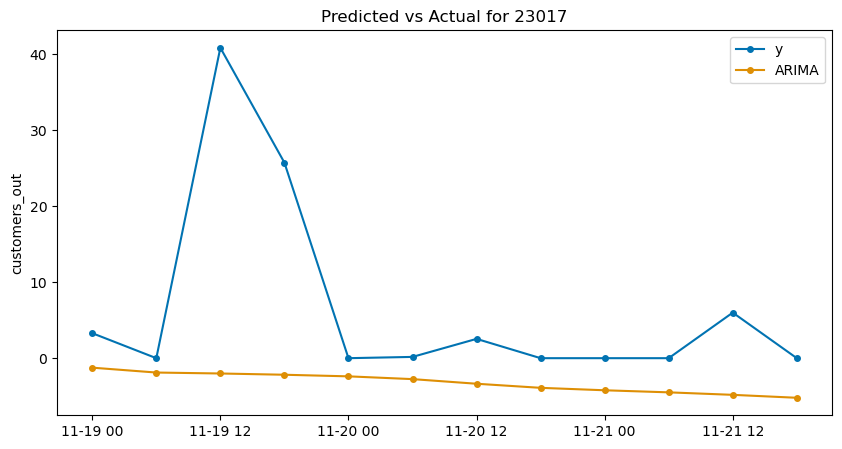

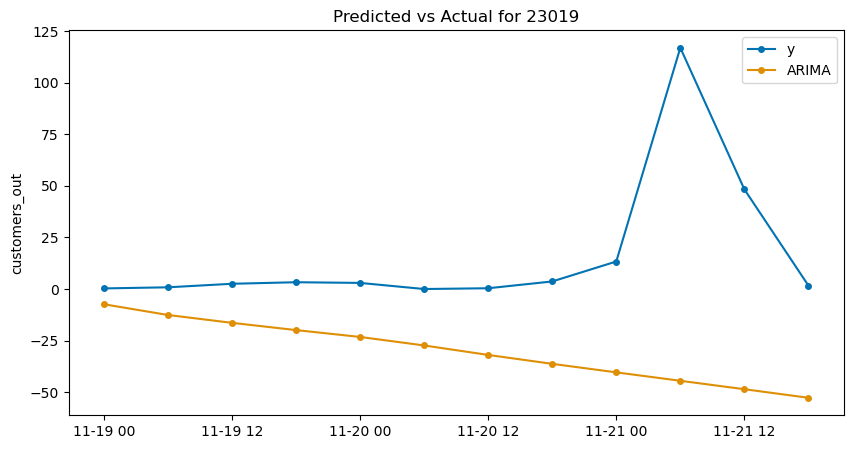

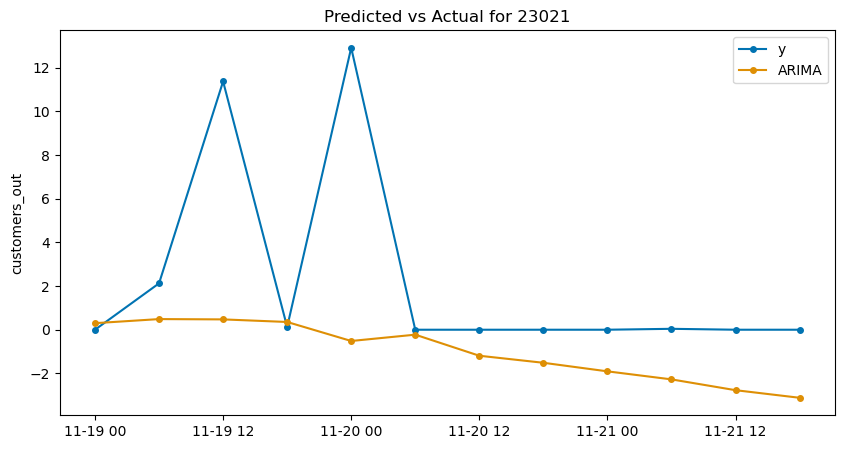

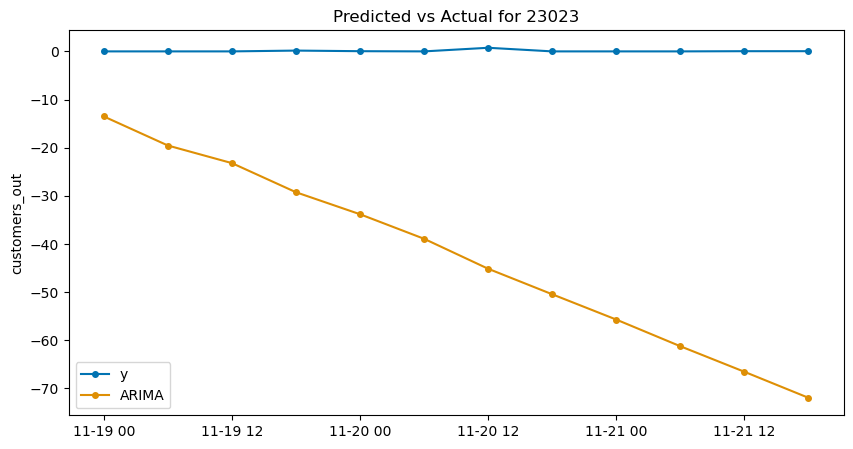

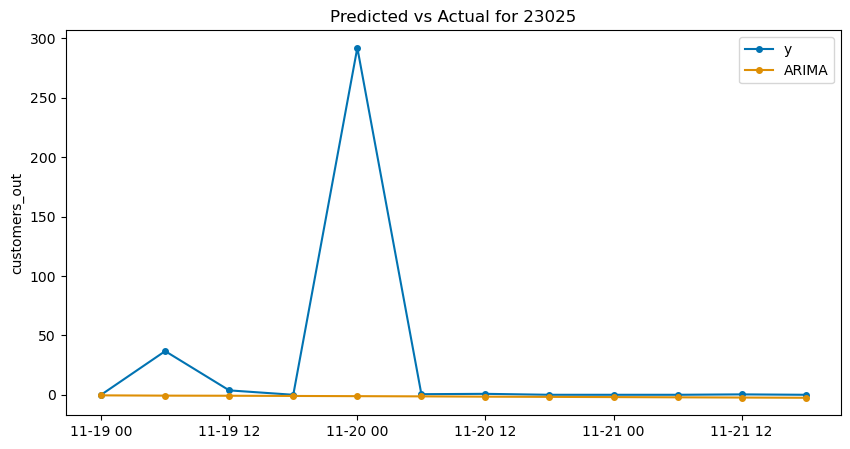

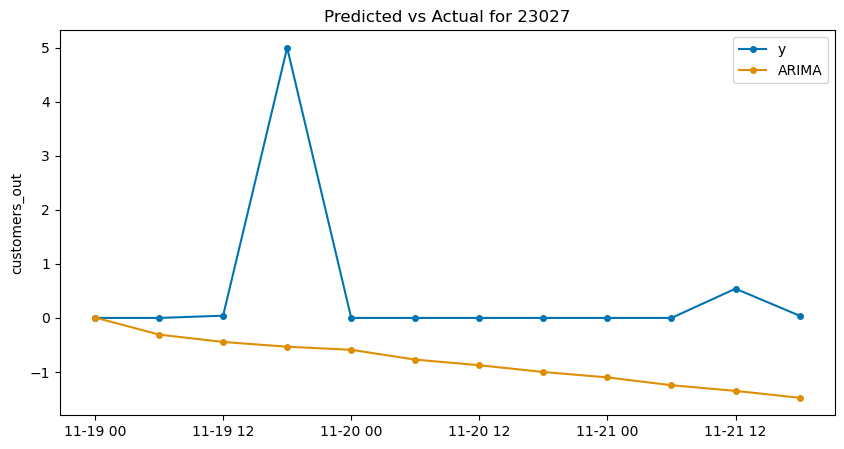

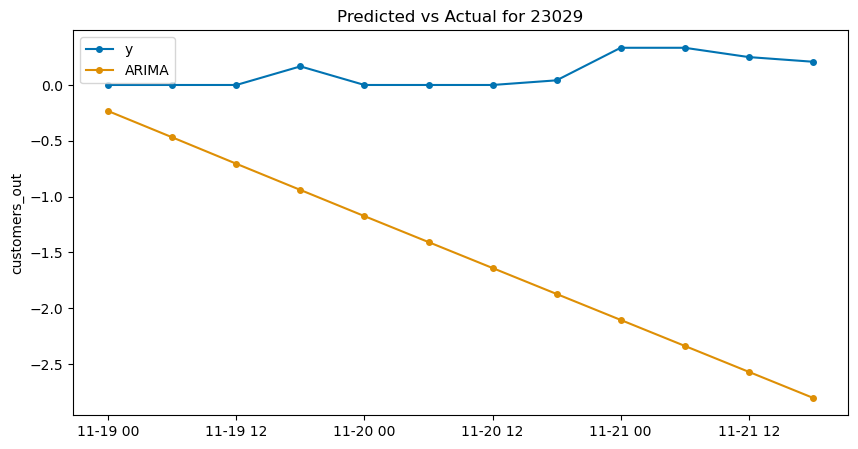

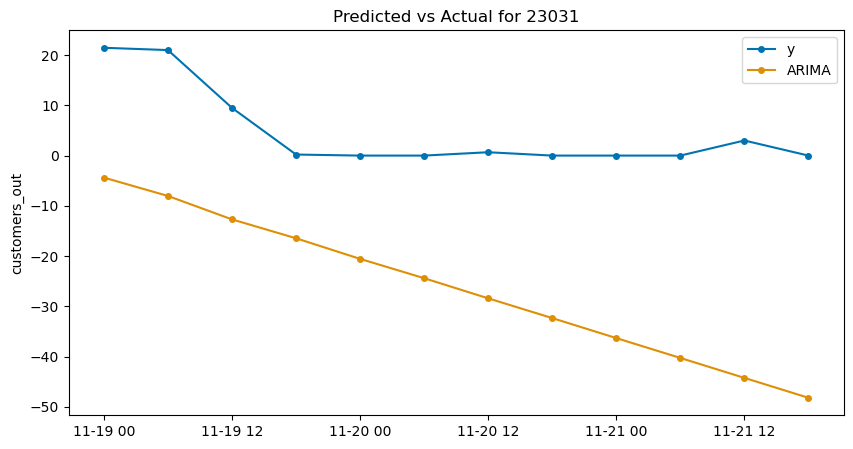

In [37]:
# Make a plot of results.y_test[0] and results.y_pred[0] for each value of fips_code
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = results.y_test[0].loc[fips_code]
    y_pred_fips = results.y_pred[0].loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_fips, labels=["y", "ARIMA"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

### Examine the predictions and scoring for each of the 160 splits

In [38]:
# We can examine the predicted values split by split
results.y_pred[0]

customers_out
fips_code datetime                       
23001     2021-11-19 00:00      -0.128775
          2021-11-19 06:00      -4.354722
          2021-11-19 12:00      -3.920500
          2021-11-19 18:00      -5.419151
          2021-11-20 00:00      11.268334
...                                   ...
23031     2021-11-20 18:00     -32.341539
          2021-11-21 00:00     -36.326419
          2021-11-21 06:00     -40.277694
          2021-11-21 12:00     -44.248364
          2021-11-21 18:00     -48.206510

[192 rows x 1 columns]

In [39]:
# We can access the RMSE scores

results.test_MeanSquaredError

# This is the same as the following code:
# mse = MeanSquaredError(square_root = True)
# for i in range(161):
#     print(i, ':', mse(results.y_test[i], results.y_pred[i]))


# If we were using MAPE, we could see the scoring by using:
# results.test_MeanAbsolutePercentageError

# This is the same as the following code:
# mape = MeanAbsolutePercentageError(symmetric=False)
# for i in range(161):
#     print(i,':',mape(results.y_test[i], results.y_pred[i]))

0      3.002197e+01
1      2.196765e+01
2      2.801244e+01
3      3.322081e+01
4      3.840516e+01
           ...     
156    1.681681e+01
157    2.124885e+01
158    4.693235e+01
159    8.755585e+06
160    9.495944e+03
Name: test_MeanSquaredError, Length: 161, dtype: float64

### Make a plot of the train and test windows

This doesn't really do much other than show that the cv splitter seemed to be working

In [19]:
#Sample code from the website

from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_windows(y, train_windows, test_windows, title=""):
    """Visualize training and test windows."""
    simplefilter("ignore", category=UserWarning)

    def get_y(length, split):
        # Create a constant vector based on the split for y-axis."""
        return np.ones(length) * split

    n_splits = len(train_windows)
    n_timepoints = len(y)
    len_test = len(test_windows[0])

    train_color, test_color = sns.color_palette("colorblind")[:2]

    fig, ax = plt.subplots(figsize=plt.figaspect(0.3))

    for i in range(n_splits):
        train = train_windows[i]
        test = test_windows[i]

        ax.plot(
            np.arange(n_timepoints), get_y(n_timepoints, i), marker="o", c="lightgray"
        )
        ax.plot(
            train,
            get_y(len(train), i),
            marker="o",
            c=train_color,
            label="Window",
        )
        ax.plot(
            test,
            get_y(len_test, i),
            marker="o",
            c=test_color,
            label="Forecasting horizon",
        )
    ax.invert_yaxis()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(
        title=title,
        ylabel="Window number",
        xlabel="Time",
        xticklabels=y.index,
    )
    # remove duplicate labels/handles
    handles, labels = ((leg[:2]) for leg in ax.get_legend_handles_labels())
    ax.legend(handles, labels)

    # Some helper code from sktime

def get_windows(y, cv):
    """Generate windows."""
    train_windows = []
    test_windows = []
    for i, (train, test) in enumerate(cv.split(y)):
        train_windows.append(train)
        test_windows.append(test)
    return train_windows, test_windows

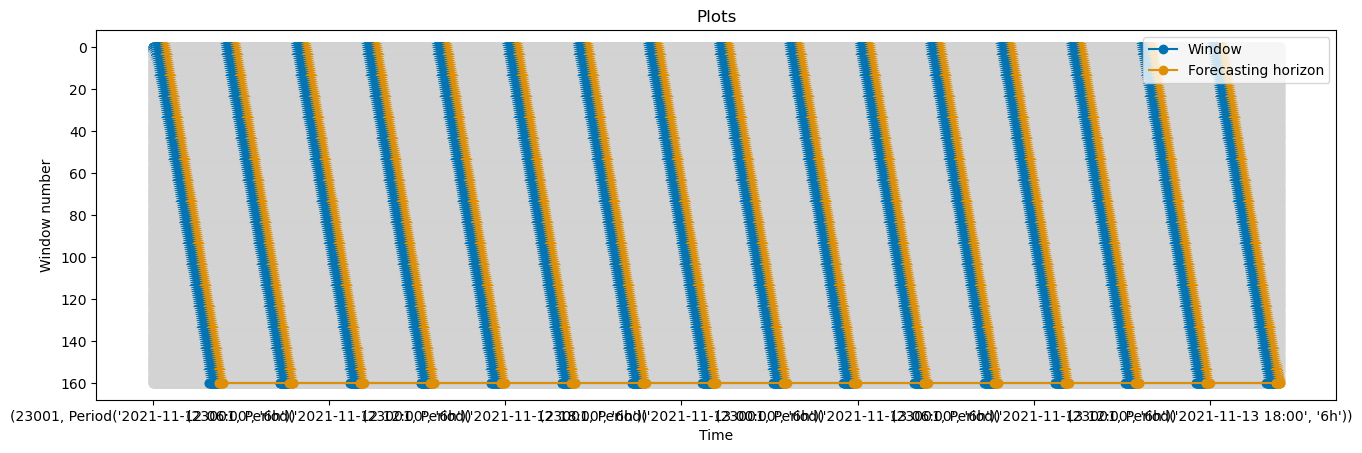

In [20]:
train_windows, test_windows = get_windows(y_small, sw)

plot_windows(y_small, train_windows, test_windows, title="Plots")

### Manual predictions and evaluation

An alternative to the evaluate method is to run the slidingwindowsplitter manually to generate predictions 

In [44]:
# Set up the ARIMA forecaster with order 5
forecaster_arima = ARIMA(order=(5, 1, 0), enforce_stationarity=False, enforce_invertibility=False)

# Define the SlidingWindowSplitter
sw = SlidingWindowSplitter(
    window_length=28,       # Length of the training window
    fh = np.arange(1,13),   # Forecasting horizon
    step_length=1)          # Step length between windows

#Use sw to make predictions for y_small
mse = MeanSquaredError(square_root = True)
fh = np.arange(1, 13)


results = []
i=0
# Note that sw.split(y_small) creates an array of arrays of (groups of) indices (orgahnized by the hierarchical structure)
# With the splitter specified above, the first value of test would be the array [28..39 228..239 ...]
# that is, the indices for the first 12-values (starting at 29 for the first county, 228 for the second county, etc.)
# We can find the corresponding customers_out values by using y_small.iloc[train_idx]
for train_idx, test_idx in sw.split(y_small):
    # Split the data
    y_small_train, y_small_test = y_small.iloc[train_idx], y_small.iloc[test_idx]
    
    # Fit the model
    forecaster_arima.fit(y_small_train)
    
    # Predict
    y_small_pred = forecaster_arima.predict(fh=sw.fh)
    
    # Calculate performance metric
    rmse = mse(y_small_test, y_small_pred)
    
    # Store the results
    results.append((i, rmse))
    i=i+1

/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

In [45]:
for i, rmse in results:
    print('Iteration', i, f"RMSE: {rmse}")
    #print("-" * 50)

Iteration 0 RMSE: 30.02196953316674
Iteration 1 RMSE: 21.96765282193953
Iteration 2 RMSE: 28.01244278083863
Iteration 3 RMSE: 33.22081109665754
Iteration 4 RMSE: 38.40516496623417
Iteration 5 RMSE: 37.65647868098257
Iteration 6 RMSE: 35.980396217589366
Iteration 7 RMSE: 47.48636151240003
Iteration 8 RMSE: 1175031.6109399719
Iteration 9 RMSE: 47495.317803943595
Iteration 10 RMSE: 24334.708634884984
Iteration 11 RMSE: 1508.2097192112376
Iteration 12 RMSE: 1710.3545410959985
Iteration 13 RMSE: 52.97221584497405
Iteration 14 RMSE: 325.98325043424575
Iteration 15 RMSE: 1.0097288840222394e+30
Iteration 16 RMSE: 6.2445193896964376e+16
Iteration 17 RMSE: 60970159907.78147
Iteration 18 RMSE: 586843551.4680115
Iteration 19 RMSE: 828169.622288998
Iteration 20 RMSE: 1957.6918848500586
Iteration 21 RMSE: 2756.4298843701954
Iteration 22 RMSE: 2388.4997084208044
Iteration 23 RMSE: 2509.69162590034
Iteration 24 RMSE: 111.16451704155173
Iteration 25 RMSE: 73.43289048065726
Iteration 26 RMSE: 79.0808551

# Prediction with exogenous variables

## Set up the features and data

In [ ]:
features = ['event_count SnowIce',
       'event_count Flood', 'event_count Storm', 'event_count Hurricane',
       'event_count Heat', 'event_count Fire', 'event_count Wind',
       'event_count Ocean', 'event_count Other', 't2m', 'sf', 'tp', 't2m_mean',
       't2m_max', 'sf_mean', 'sf_max', 'tp_mean', 'tp_max', 'wind_speed',
       'neighbor_mean_wind_speed', 'neighbor_max_wind_speed', 'sf_12h',
       'sf_24h', 'tp_12h', 'tp_24h']

y = df['customers_out']
X = df[features]

# Restrict to a smaller data set for testing purposes
y_small = y.groupby(level=0).tail(200)


#Set the multiindex on y and X
y = y.reset_index()
X = X.reset_index()

#Use fips_code and datetime as a multiindex
y = y.set_index(['fips_code', 'datetime'])
X = X.set_index(['fips_code', 'datetime'])

#Sort
y = y.sort_index()
X = X.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)
X.index = X.index.set_levels(X.index.levels[1].to_period('6h'), level=1)

## VARIMAX model with a single split

### Setting up a VARIMAX model to compare with ARIMA

In [ ]:
y_train, y_test = temporal_train_test_split(y, test_size=30)
# Note that y_train and y_test are each a dataframe with values of customers_out and a multiindex with fips_code and datetime indices

fh = ForecastingHorizon(y_test.index.get_level_values('datetime').unique(), is_relative=False)

forecaster_arima = ARIMA(order=(5, 1, 0))
forecaster_arima.fit(y_train)

forecaster_naive = NaiveForecaster(strategy="last", sp=1460)
forecaster_naive.fit(y_train)

y_pred_arima = forecaster_arima.predict(fh)
y_pred_naive = forecaster_naive.predict(fh)

In [ ]:
# Make plots for each fips_code to compare actual and predicted values on the test set
for fips_code in y.index.get_level_values(0).unique():
    y_train_fips = y_train.loc[fips_code]
    y_test_fips = y_test.loc[fips_code]
    y_pred_a = y_pred_arima.loc[fips_code]
    y_pred_n = y_pred_naive.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_a, y_pred_n, labels=["y", "ARIMA","Naive"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

In [ ]:
#Evaluating the performance of the model

# We'll display the output in a Pandas dataframe because it looks nice.

mape = MeanAbsolutePercentageError(symmetric=False)
mape.get_tag("lower_is_better")
rmse = MeanSquaredError(square_root = True)

#Create a data frame to hold the fips code, MAPE for ARIMA and Naive predictions, and RMSE for ARIMA and Naive predictions
results = pd.DataFrame()
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = y_test.loc[fips_code]
    y_pred_a = y_pred_arima.loc[fips_code]
    y_pred_n = y_pred_naive.loc[fips_code]
    new_row = pd.DataFrame(np.zeros((1, 5)), columns=['fips_code', 'MAPE_ARIMA', 'MAPE_Naive', 'RMSE_ARIMA', 'RMSE_Naive'])
    new_row['fips_code'] = fips_code
    new_row['MAPE_ARIMA'] = mape(y_test_fips, y_pred_a)
    new_row['MAPE_Naive'] = mape(y_test_fips, y_pred_n)
    new_row['RMSE_ARIMA'] = rmse(y_test_fips, y_pred_a)
    new_row['RMSE_Naive'] = rmse(y_test_fips, y_pred_n)
    results = pd.concat([results, new_row], ignore_index=True)

results

## VARIMAX with a sliding window

In [ ]:
# Set up the ARIMA forecaster with order 5
forecaster_arima = ARIMA(order=(5, 1, 0), enforce_stationarity=False, enforce_invertibility=False)

# Let y_small be the most recent 200 observations of y for each value of fips_code
y_small = y.groupby(level=0).tail(200)

fh = np.arange(1, 13)   #Forecasting horizon - we'll need this later
#fh = ForecastingHorizon(13, is_relative=False)

# Define the SlidingWindowSplitter
sw = SlidingWindowSplitter(
    window_length=28,       # Length of the training window
    fh = np.arange(1,13),   # Forecasting horizon
    step_length=1)          # Step length between windows

In [ ]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

results = evaluate(
    forecaster=forecaster_arima,
    cv=sw,
    y=y_small,
    X=None,             # This works with exogeneous variables; predictions are made using predict/predict_proba, or predict_quantiles depending on scoring
    strategy="refit",  # Options are "update" and "refit" (which will reset and fit forecaster via fit), verses updating forecaster via "update"
    scoring=MeanSquaredError(square_root = True),       # None defaults to MeanAbsolutePercentageError(symmetric=True). Options at: https://www.sktime.net/en/stable/api_reference/performance_metrics.html
    return_data=True,   # True means it returns three pd.Series columns for y_train, y_pred, and y_test
    error_score="raise",
    backend=None       # (default is None) Parallelization backend; runs parallel evaluate if specified and strategy="refit"; recommendation to use "dask" or "loky"